In [39]:
import pybullet as p
import numpy as np
import matplotlib.pyplot as plt

# ================== 仿真参数 ==================
restitution_list = [1, 0.8, 0.6, 0.3, 0]      # 不同的恢复系数
gravity = -9.81                     # 重力加速度 (m/s²)
timestep = 0.001                    # 仿真步长 (s)
sim_duration = 4.0                   # 仿真时长 (s)
num_steps = int(sim_duration / timestep)

radius = 0.5
mass = 1.0
init_height = 4.5      # 球心初始高度

all_results = []

for rest_idx, rest_val in enumerate(restitution_list):
    print(f"运行仿真 {rest_idx+1}, 恢复系数 = {rest_val}")

    # 连接物理引擎
    p.connect(p.DIRECT)
    p.setGravity(0, 0, gravity)
    p.setTimeStep(timestep)

    # ---------- 关键优化参数 ----------
    p.setPhysicsEngineParameter(useSplitImpulse=True)       # 启用分离脉冲解决穿透
    # p.setPhysicsEngineParameter(numSolverIterations=300)    # 提高迭代次数（可更高）
    
    # 彻底杜绝惩罚力补充能量：
    p.setPhysicsEngineParameter(
        contactERP=0.0,                   # 【关键】把接触穿透的惩罚力设为0，杜绝能量注入
        # restitutionVelocityThreshold=0.0, # 确保恢复系数在任何微小速度下都生效
        # contactBreakingThreshold=0.001 
    )
    # 加载地面
    import pybullet_data
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")

    # 创建小球
    col_sphere = p.createCollisionShape(p.GEOM_SPHERE, radius=radius)
    vis_sphere = p.createVisualShape(p.GEOM_SPHERE, radius=radius, rgbaColor=[1, 0, 0, 1])
    sphere_id = p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=col_sphere,
        baseVisualShapeIndex=vis_sphere,
        basePosition=[0, 0, init_height]
    )

    # ---------- 接触刚度和阻尼设置 ----------
    # 设置极高的接触刚度，极低的接触阻尼，使接触更接近理想弹性
    p.changeDynamics(plane_id, -1, restitution=1.0)
    p.changeDynamics(sphere_id, -1, restitution=rest_val)
    p.changeDynamics(sphere_id, -1, linearDamping=0, angularDamping=0)
    # p.changeDynamics(plane_id, -1, contactStiffness=2e8, contactDamping=0)
    # p.changeDynamics(sphere_id, -1, contactStiffness=2e8, contactDamping=0)
    # 打印当前参数，确认设置生效
    print(p.getPhysicsEngineParameters())

    # 记录数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    for i in range(num_steps):
        time_points[i] = i * timestep
        pos, _ = p.getBasePositionAndOrientation(sphere_id)
        vel, _ = p.getBaseVelocity(sphere_id)
        height_points[i] = pos[2] - radius
        velocity_points[i] = vel[2]
        p.stepSimulation()

    p.disconnect()

    all_results.append({
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'restitution': rest_val
    })
    print(f"仿真 {rest_idx+1} 完成")

# 绘制结果（略，同之前）

运行仿真 1, 恢复系数 = 1
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 1 完成
运行仿真 2, 恢复系数 = 0.8
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 2 完成
运行仿真 3, 恢复系数 = 0.6
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 3 完成
运行仿真 4, 恢复系数 = 0.3
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 4 完成
运行仿真 5

恢复系数 e=1 的峰值时间和高度：
  时间: 1.807 s, 高度: 4.00886824 m
  时间: 3.617 s, 高度: 4.01774629 m
恢复系数 e=0.8 的峰值时间和高度：
  时间: 1.627 s, 高度: 2.5649421880000105 m
  时间: 2.930 s, 高度: 1.6462533460000106 m
  时间: 3.973 s, 高度: 1.0574405867200103 m
恢复系数 e=0.6 的峰值时间和高度：
  时间: 1.446 s, 高度: 1.4416913020000146 m
  时间: 2.316 s, 高度: 0.5183203432000096 m
  时间: 2.837 s, 高度: 0.18758388424000516 m
  时间: 3.151 s, 高度: 0.06791856908800475 m
  时间: 3.342 s, 高度: 0.02432330265280669 m
  时间: 3.456 s, 高度: 0.008818176686084978 m
  时间: 3.525 s, 高度: 0.0033313841040704117 m
  时间: 3.569 s, 高度: 0.0012302271853377178 m
恢复系数 e=0.3 的峰值时间和高度：
  时间: 1.175 s, 高度: 0.3580806640000209 m
  时间: 1.527 s, 高度: 0.03248362480001443 m
  时间: 1.634 s, 高度: 0.0024393226000151147 m
  时间: 1.664 s, 高度: 0.00018994061201416113 m
恢复系数 e=0 的峰值时间和高度：


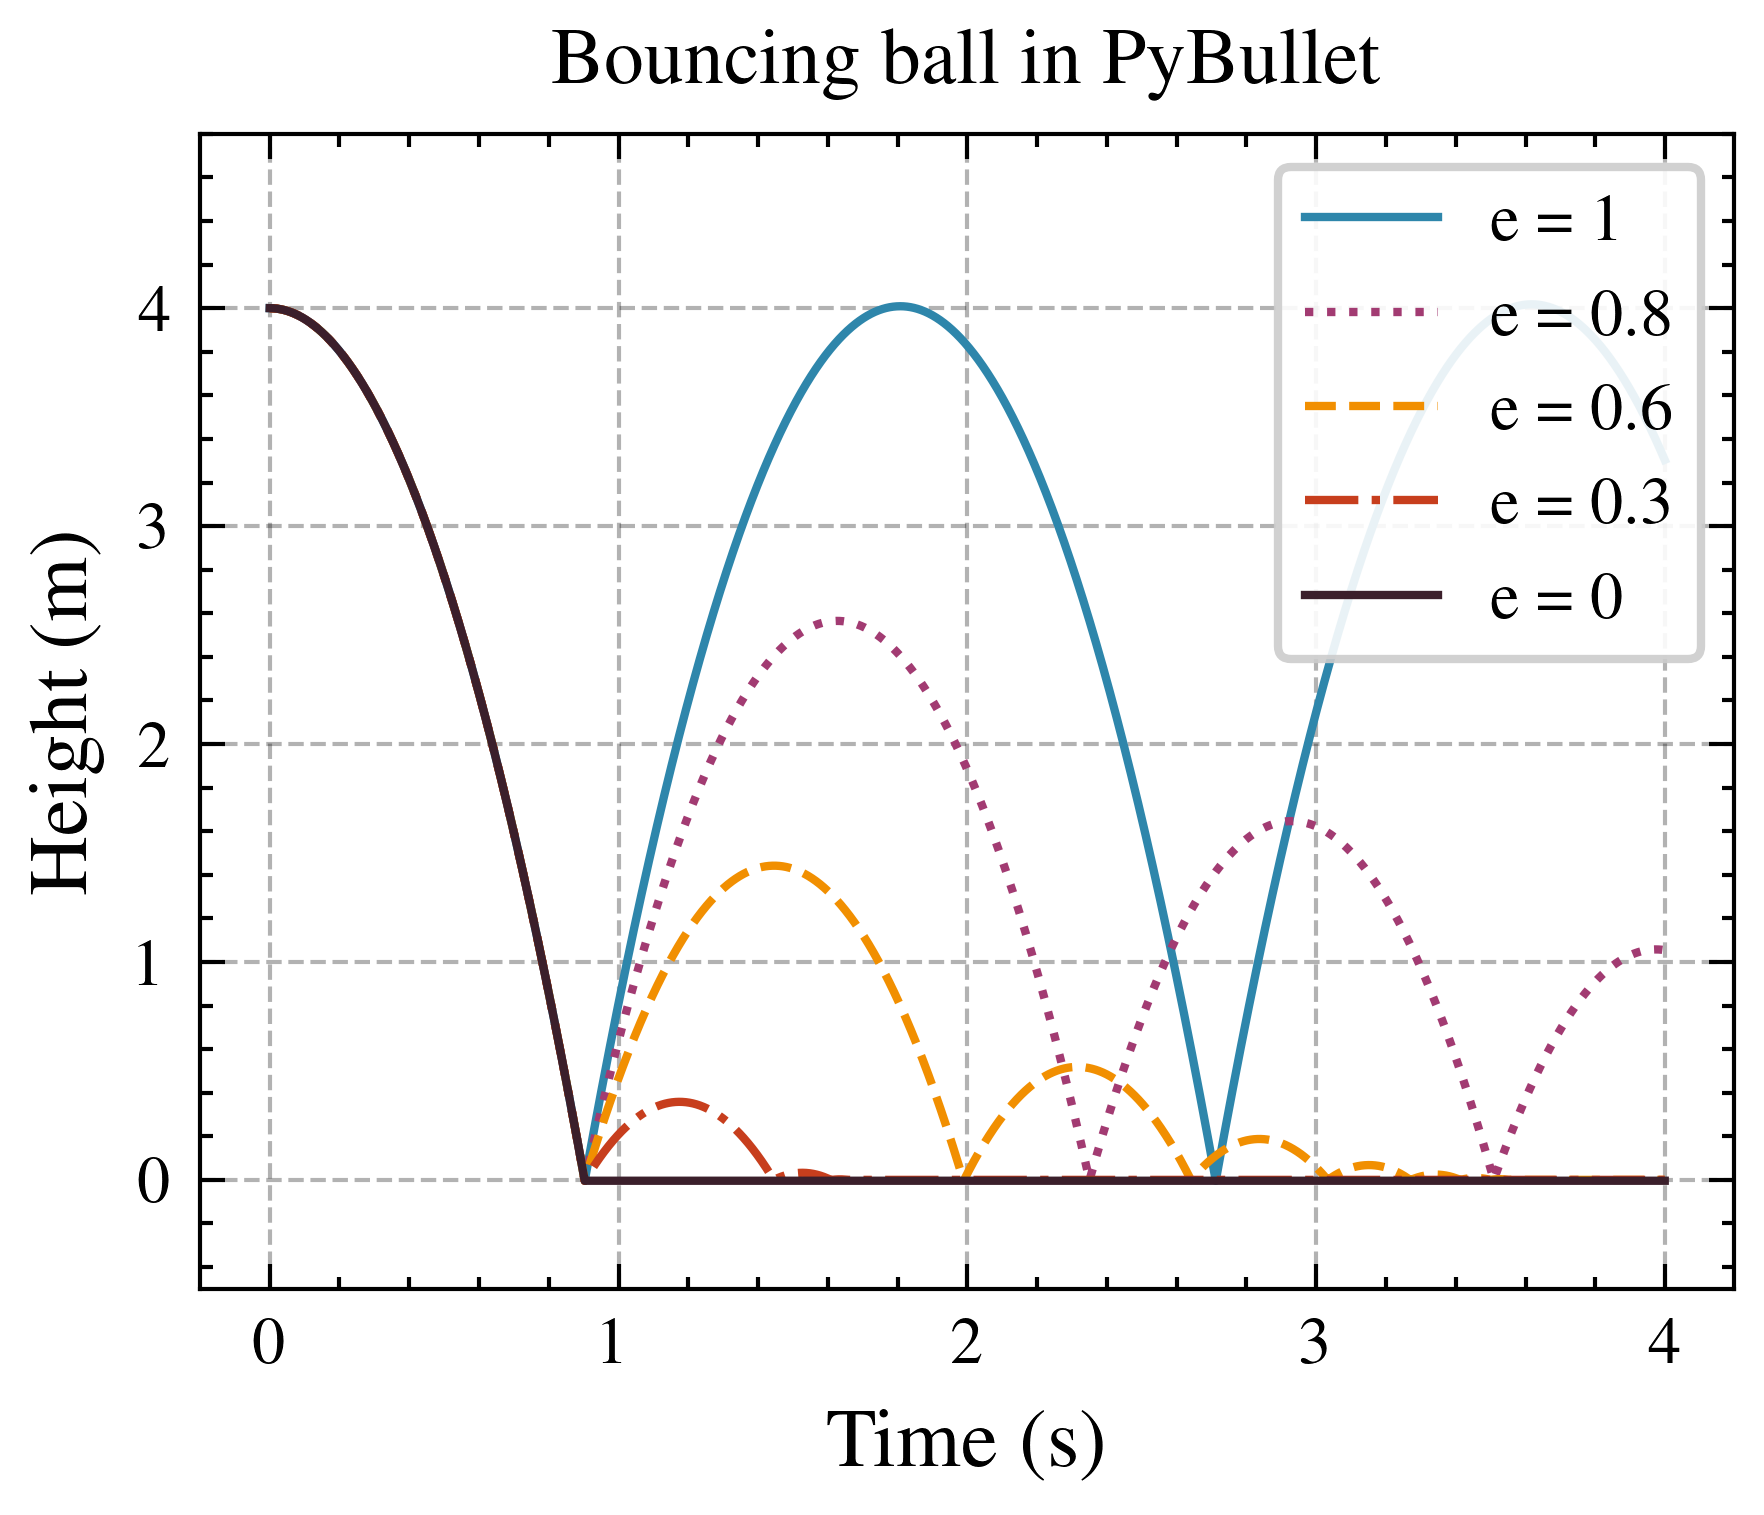

In [42]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# ================== 绘制结果 ==================
# 设置字体（避免中文乱码，若无中文字体可注释）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['science', 'ieee', 'grid'])

# 定义线型和颜色
linestyles = ["-", ":", "--", "-."]
scientific_colors = [
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
    '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
]

# get max height for every bounce
for result in all_results:
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    # 找到所有峰值（反弹最高点）
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(height)
    peak_times = time[peaks]
    peak_heights = height[peaks]

    print(f"恢复系数 e={rest_val} 的峰值时间和高度：")
    for t, h in zip(peak_times, peak_heights):
        print(f"  时间: {t:.3f} s, 高度: {h} m")

# 绘制高度曲线
# plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
# plt.legend(framealpha=0.9, loc="upper right")
# plt.xlabel('Time (s)')
# plt.ylabel('Height (m)')
# plt.title('Bouncing Ball by PyBullet')
# plt.tight_layout()
# plt.show()
plt.legend(framealpha=0.9, loc="upper right")
plt.ylim(top=4.8, bottom=-0.5)
# plt.ylim(top=5.5, bottom=-0.5)
plt.ylabel(r'Height (m)', fontsize=10)
plt.xlabel(r'Time (s)', fontsize=10)
plt.title('Bouncing ball in PyBullet')
plt.grid(True, alpha=0.3)
# plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

for i, result in enumerate(all_results):
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
# plt.legend(framealpha=0.9, loc="upper right")
# plt.xlabel('Time (s)')
# plt.ylabel('Height (m)')
# plt.title('Bouncing Ball by PyBullet')
# plt.tight_layout()
# plt.show()
plt.legend(framealpha=0.9, loc="upper right")
plt.ylim(top=4.8, bottom=-0.5)
# plt.ylim(top=5.5, bottom=-0.5)
plt.ylabel(r'Height (m)', fontsize=10)
plt.xlabel(r'Time (s)', fontsize=10)
# plt.title('Bouncing ball in PyBullet')
plt.grid(True, alpha=0.3)
# plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_bullet_hard.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.close()

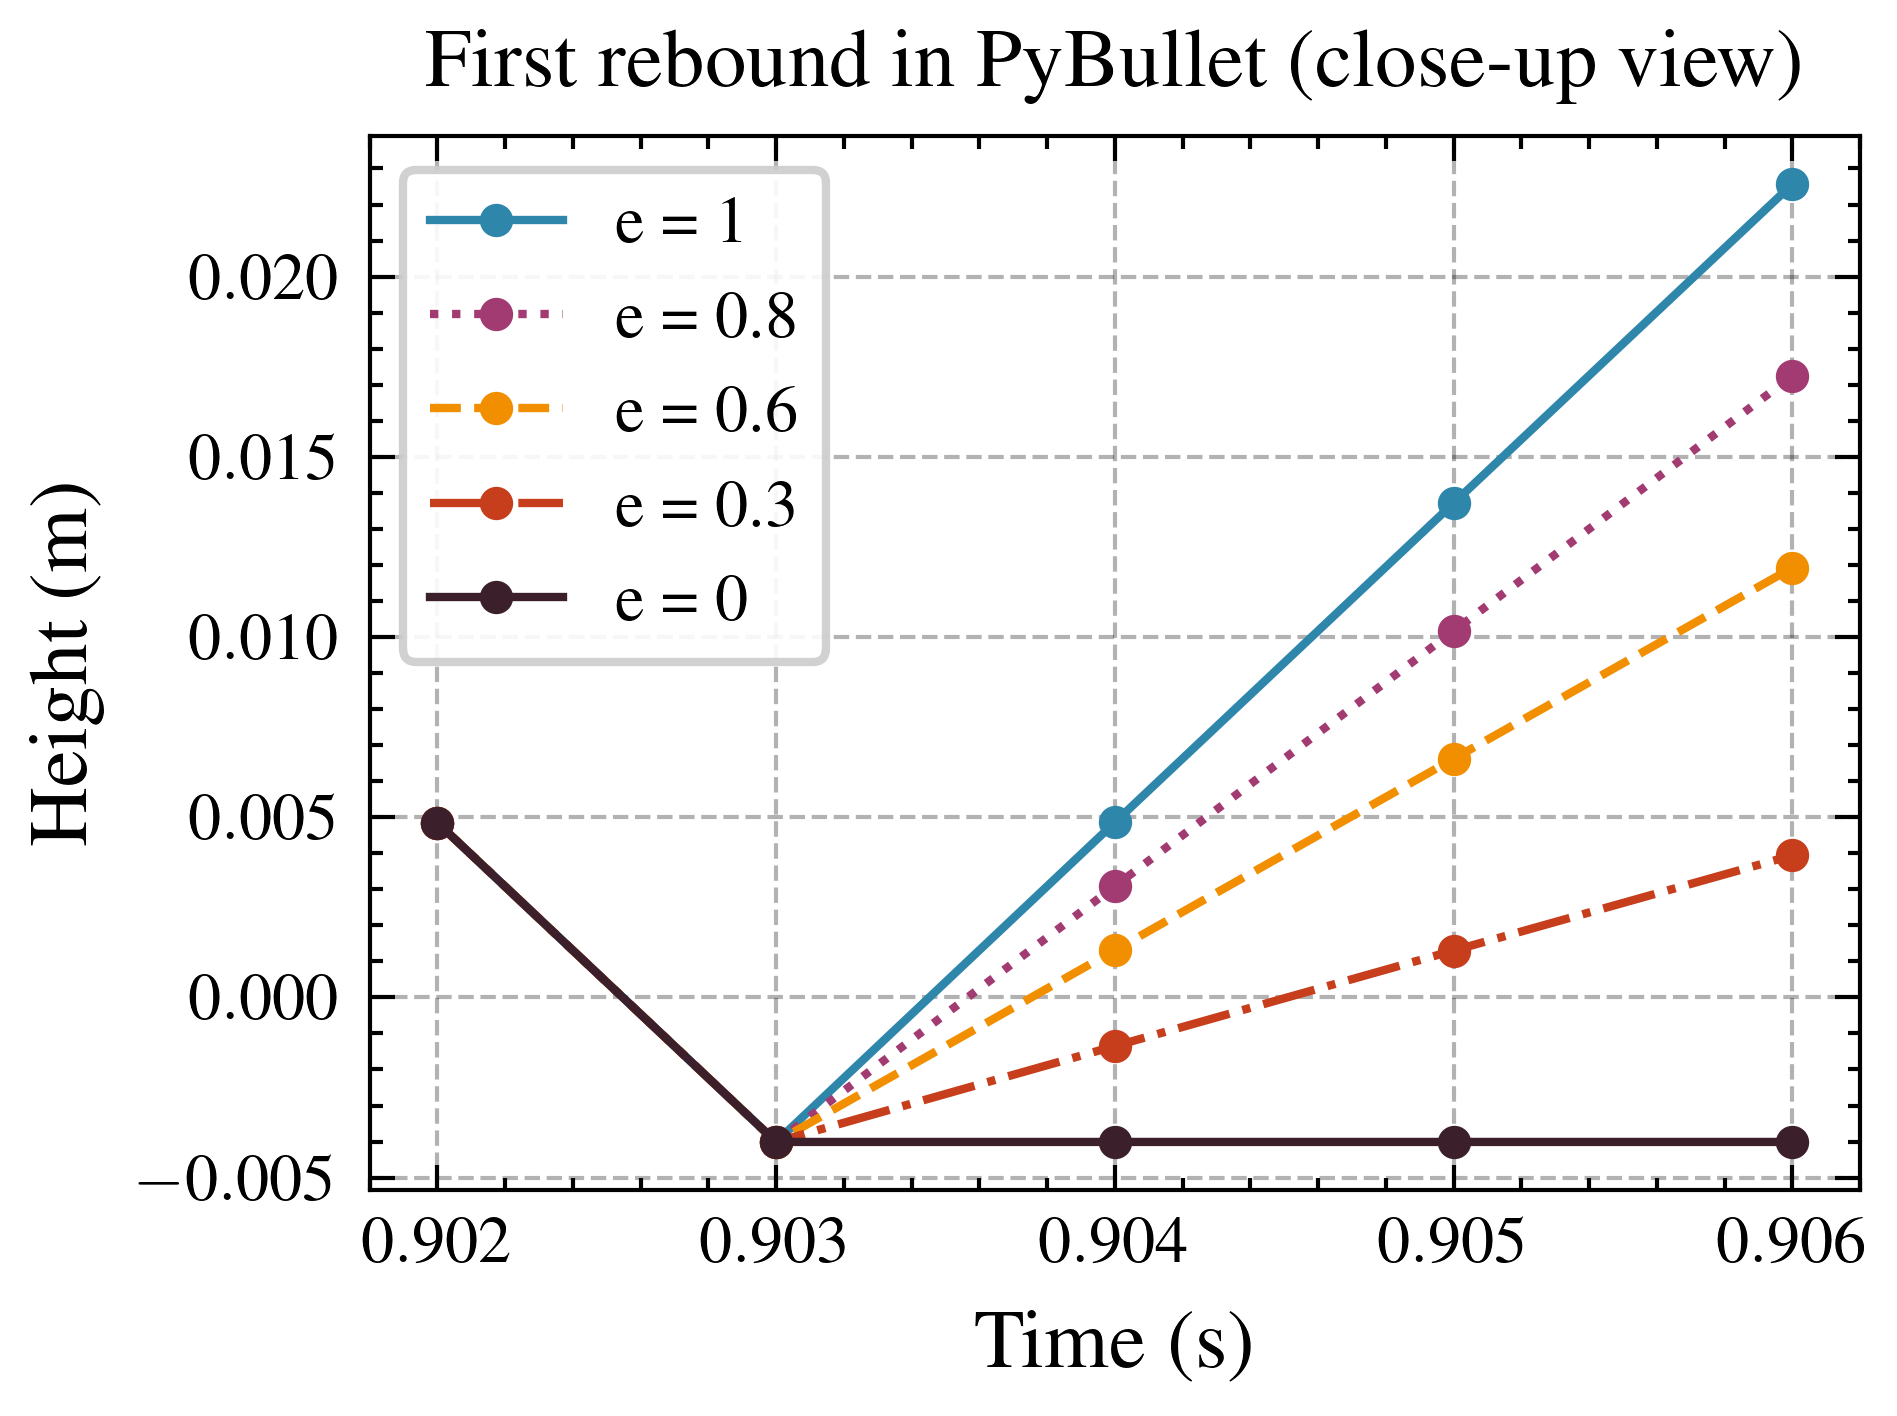

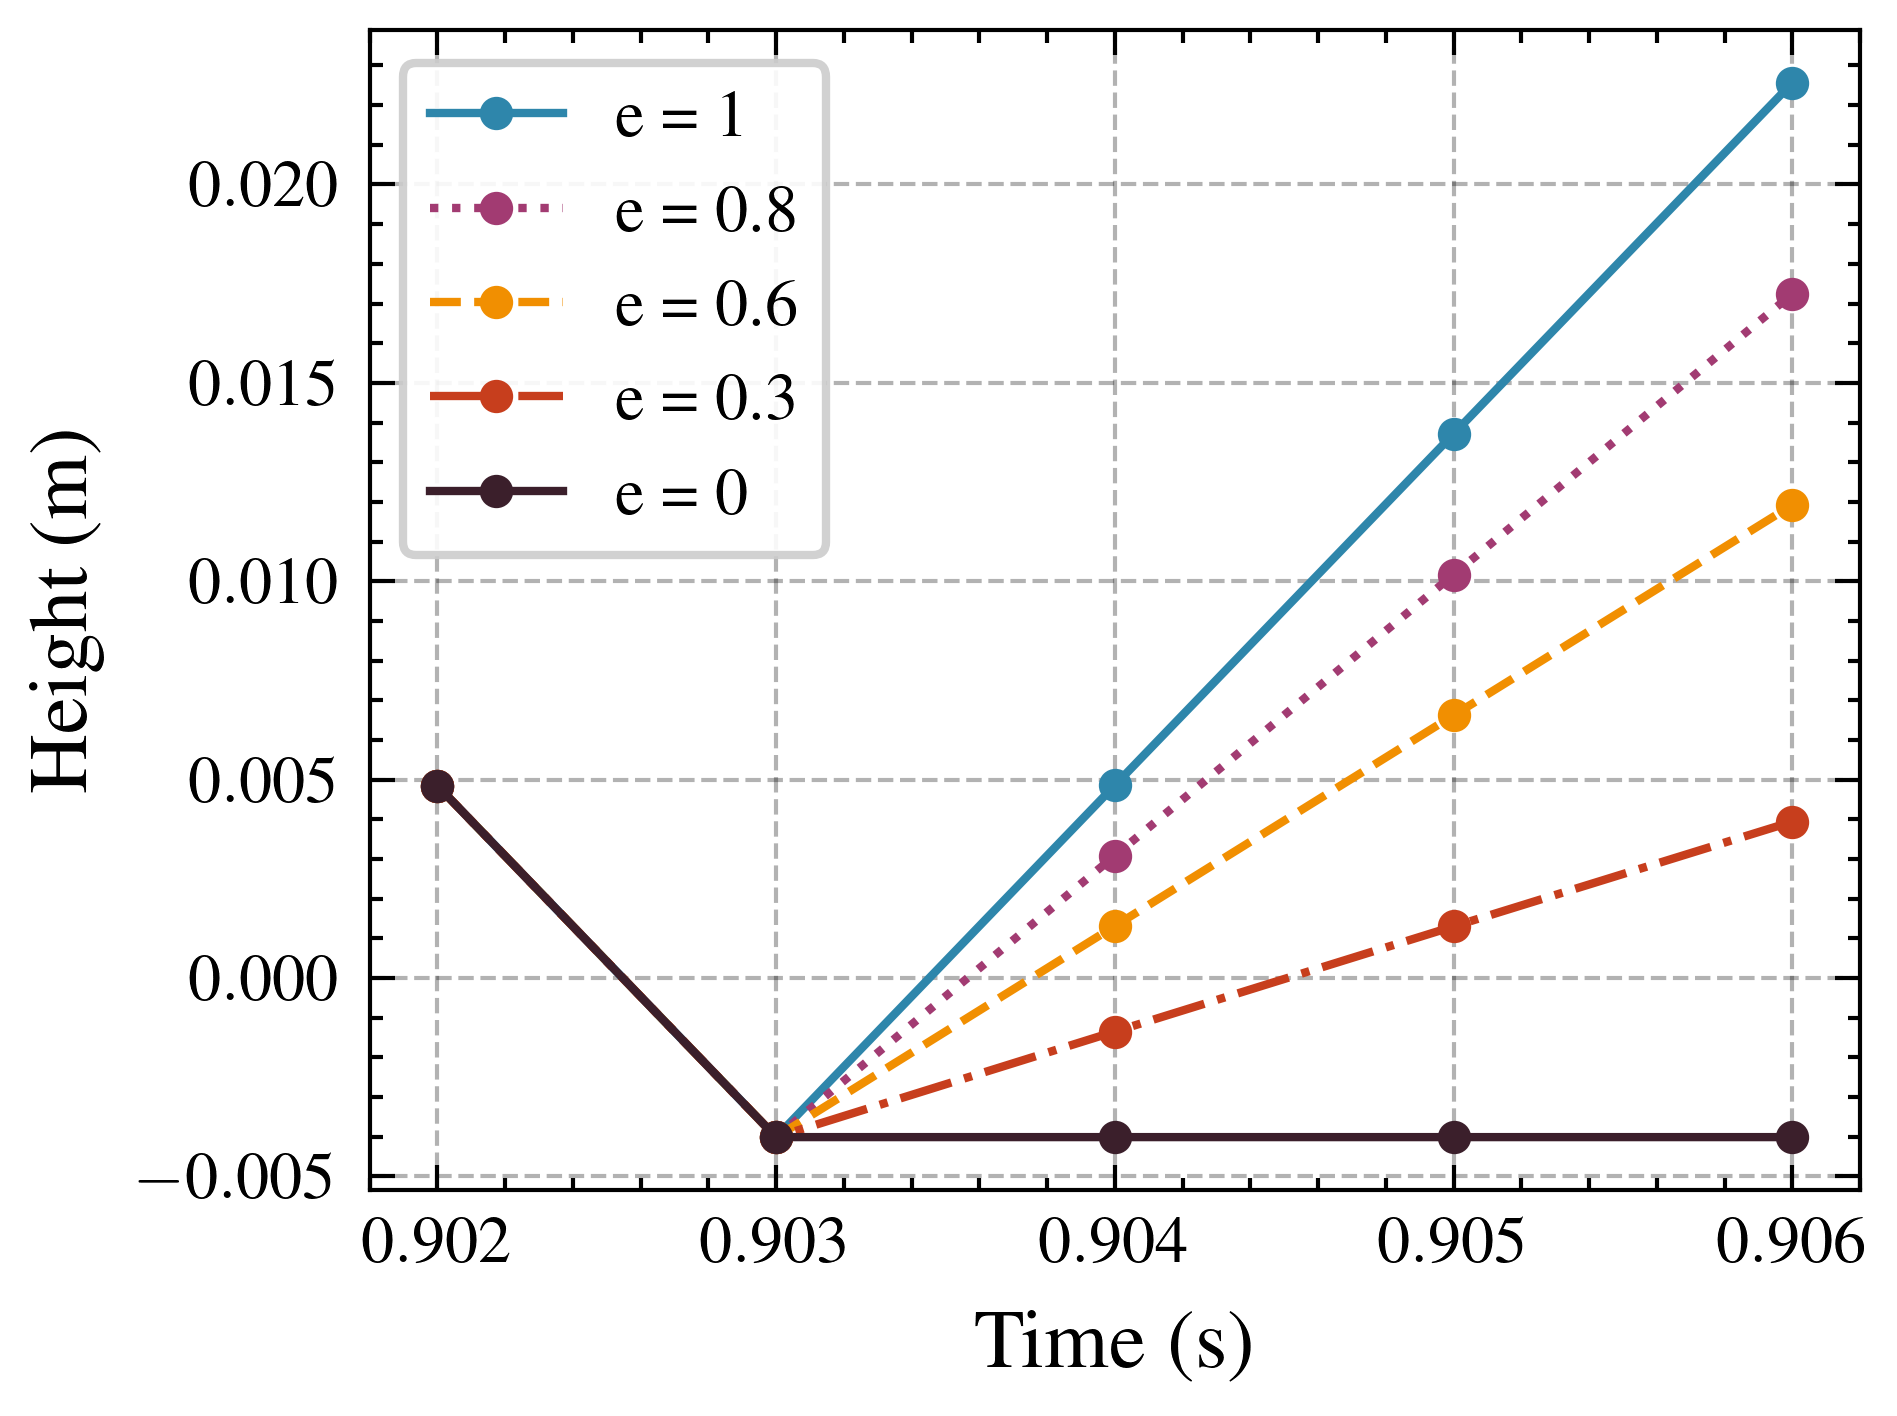

In [ ]:
# 绘制高度曲线
# plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    # 选择第一次接触地面附近的数据作图
    time = result['time'][902:907]
    height = result['height'][902:907]
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             marker='o', markersize=3,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
plt.legend(framealpha=0.9, loc="best")
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
plt.title('First rebound in PyBullet (close-up view)', fontsize=10)
plt.grid(True, alpha=0.3)
# plt.ylim(bottom=-0.2, top=4.8)
plt.tight_layout()
# plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close()
for i, result in enumerate(all_results):
    # 选择第一次接触地面附近的数据作图
    time = result['time'][902:907]
    height = result['height'][902:907]
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             marker='o', markersize=3,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
plt.legend(framealpha=0.9, loc="best")
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
# plt.title('First rebound in PyBullet (close-up view)', fontsize=10)
plt.grid(True, alpha=0.3)
# plt.ylim(bottom=-0.2, top=4.8)
plt.tight_layout()
plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_bullet_hard_zoomed.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.close()

In [47]:
import pybullet as p
import numpy as np
import matplotlib.pyplot as plt

# ================== 仿真参数 ==================
# restitution_list = [0, 0.3, 0.6, 0.8, 1]      # 不同的恢复系数
restitution_list = [2e4, 2e5]      # 不同的恢复系数
gravity = -9.81                     # 重力加速度 (m/s²)
timestep = 0.001                    # 仿真步长 (s)
sim_duration = 4.0                   # 仿真时长 (s)
num_steps = int(sim_duration / timestep)

radius = 0.5
mass = 1.0
init_height = 4.5      # 球心初始高度

all_results = []

for rest_idx, rest_val in enumerate(restitution_list):
    print(f"运行仿真 {rest_idx+1}, 恢复系数 = {rest_val}")

    # 连接物理引擎
    p.connect(p.DIRECT)
    p.setGravity(0, 0, gravity)
    p.setTimeStep(timestep)

    # ---------- 关键优化参数 ----------
    p.setPhysicsEngineParameter(useSplitImpulse=True)       # 启用分离脉冲解决穿透
    # p.setPhysicsEngineParameter(numSolverIterations=300)    # 提高迭代次数（可更高）
    
    # 彻底杜绝惩罚力补充能量：
    p.setPhysicsEngineParameter(
        contactERP=0.0,                   # 【关键】把接触穿透的惩罚力设为0，杜绝能量注入
        # restitutionVelocityThreshold=0.0, # 确保恢复系数在任何微小速度下都生效
        # contactBreakingThreshold=0.001 
    )
    # 加载地面
    import pybullet_data
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")

    # 创建小球
    col_sphere = p.createCollisionShape(p.GEOM_SPHERE, radius=radius)
    vis_sphere = p.createVisualShape(p.GEOM_SPHERE, radius=radius, rgbaColor=[1, 0, 0, 1])
    sphere_id = p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=col_sphere,
        baseVisualShapeIndex=vis_sphere,
        basePosition=[0, 0, init_height]
    )

    # ---------- 接触刚度和阻尼设置 ----------
    # 设置极高的接触刚度，极低的接触阻尼，使接触更接近理想弹性
    # p.changeDynamics(plane_id, -1, restitution=1.0)
    # p.changeDynamics(sphere_id, -1, restitution=rest_val)
    p.changeDynamics(sphere_id, -1, linearDamping=0, angularDamping=0)
    p.changeDynamics(plane_id, -1, contactStiffness=rest_val, contactDamping=0)
    p.changeDynamics(sphere_id, -1, contactStiffness=rest_val, contactDamping=0)
    # 打印当前参数，确认设置生效
    print(p.getPhysicsEngineParameters())

    # 记录数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    for i in range(num_steps):
        time_points[i] = i * timestep
        pos, _ = p.getBasePositionAndOrientation(sphere_id)
        vel, _ = p.getBaseVelocity(sphere_id)
        height_points[i] = pos[2] - radius
        velocity_points[i] = vel[2]
        p.stepSimulation()

    p.disconnect()

    all_results.append({
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'restitution': rest_val
    })
    print(f"仿真 {rest_idx+1} 完成")

# 绘制结果（略，同之前）

运行仿真 1, 恢复系数 = 20000.0
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 1 完成
运行仿真 2, 恢复系数 = 200000.0
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 2 完成


恢复系数 e=20000.0 的峰值时间和高度：
  时间: 1.708 s, 高度: 2.934343591358832 m
  时间: 3.177 s, 高度: 2.1623255008904674 m
恢复系数 e=200000.0 的峰值时间和高度：
  时间: 1.487 s, 高度: 1.6185933927142404 m
  时间: 2.429 s, 高度: 0.6263705150685979 m
  时间: 3.019 s, 高度: 0.2416025742759379 m
  时间: 3.388 s, 高度: 0.09129323428583169 m
  时间: 3.624 s, 高度: 0.03933831532253795 m
  时间: 3.779 s, 高度: 0.014710527862129452 m
  时间: 3.877 s, 高度: 0.005213337388585981 m
  时间: 3.939 s, 高度: 0.0016642808270557197 m
  时间: 3.979 s, 高度: 0.00043772531438801554 m


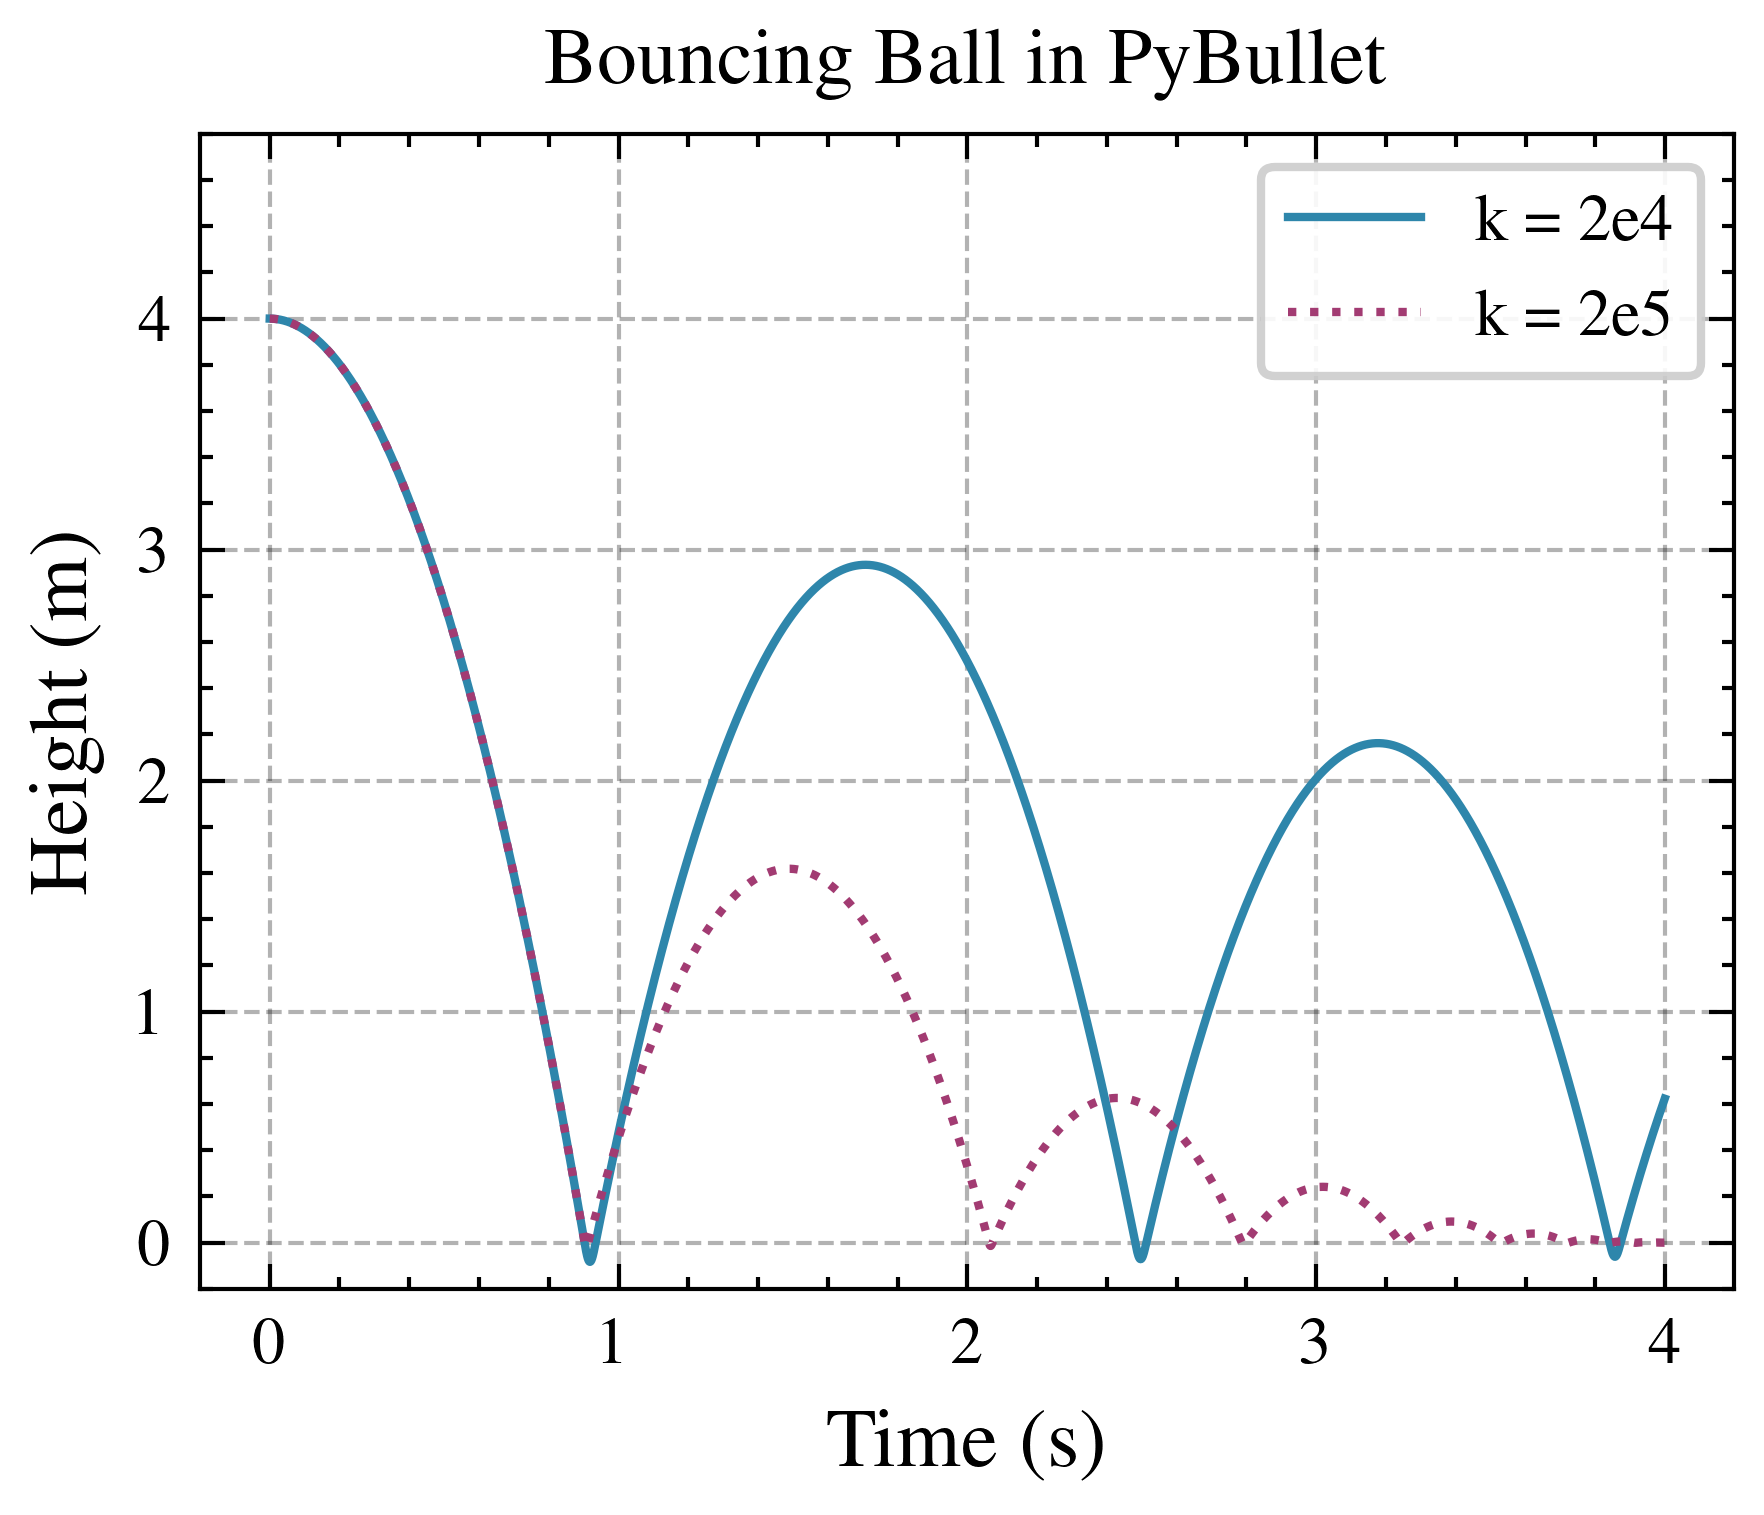

In [48]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

# ================== 绘制结果 ==================
# 设置字体（避免中文乱码，若无中文字体可注释）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['science', 'ieee', 'grid'])

# 定义线型和颜色
linestyles = ["-", ":", "--", "-."]
scientific_colors = [
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
    '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
]

# get max height for every bounce
for result in all_results:
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    # 找到所有峰值（反弹最高点）
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(height)
    peak_times = time[peaks]
    peak_heights = height[peaks]

    print(f"恢复系数 e={rest_val} 的峰值时间和高度：")
    for t, h in zip(peak_times, peak_heights):
        print(f"  时间: {t:.3f} s, 高度: {h} m")

# 绘制高度曲线
# plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             label=f"k = {simple_sci_format(rest_val)}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])

plt.legend(framealpha=0.9, loc="upper right")
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
plt.title('Bouncing Ball in PyBullet')
plt.ylim(bottom=-0.2, top=4.8)
plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close()

for i, result in enumerate(all_results):
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             label=f"k = {simple_sci_format(rest_val)}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])

plt.legend(framealpha=0.9, loc="upper right")
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
# plt.title('Bouncing Ball in PyBullet')
plt.ylim(bottom=-0.2, top=4.8)
plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_bullet_soft.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.close()

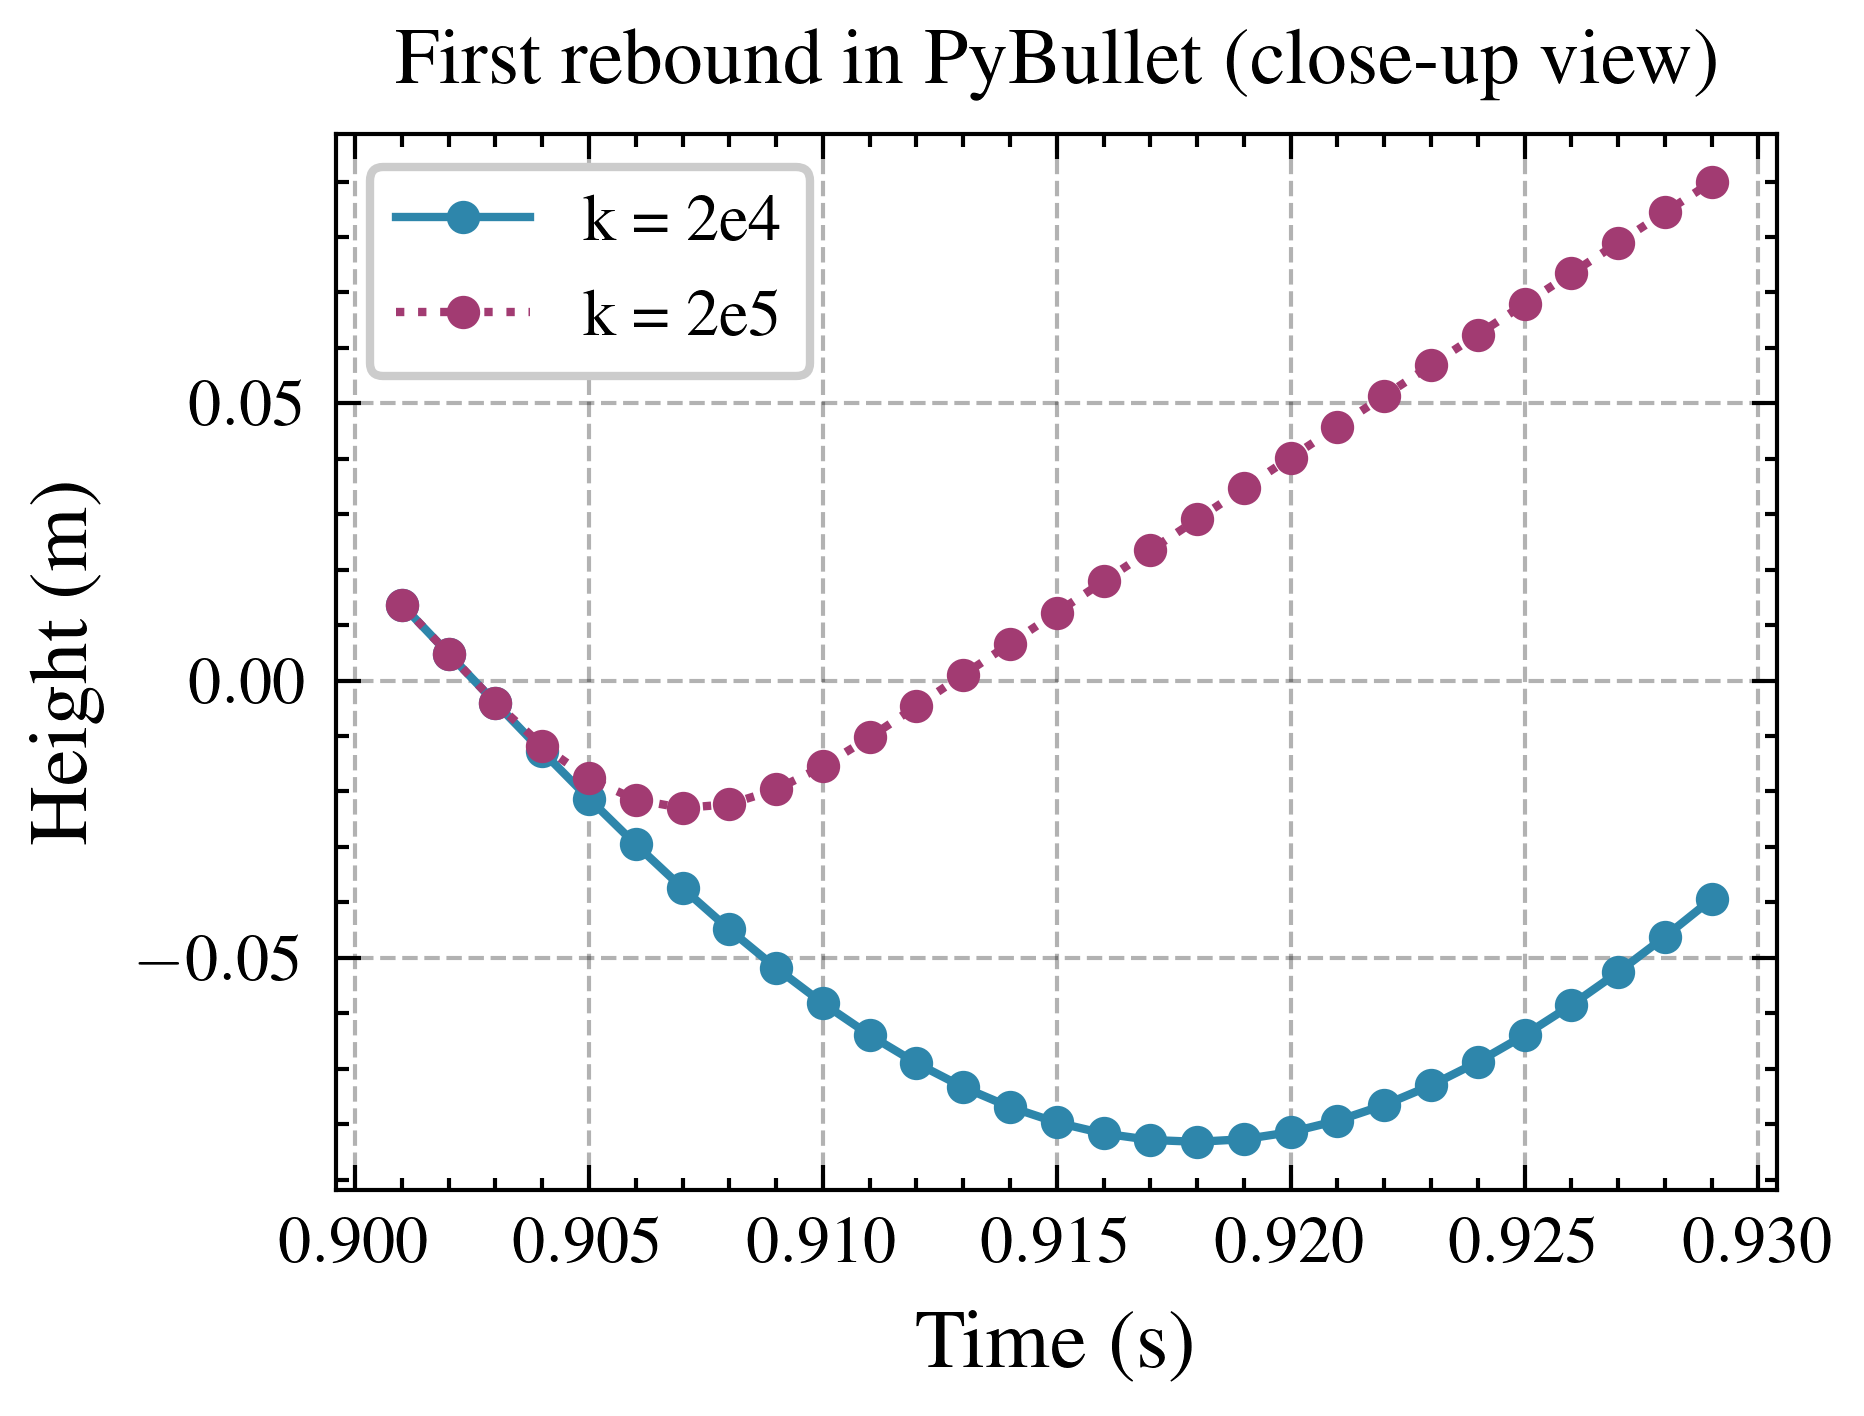

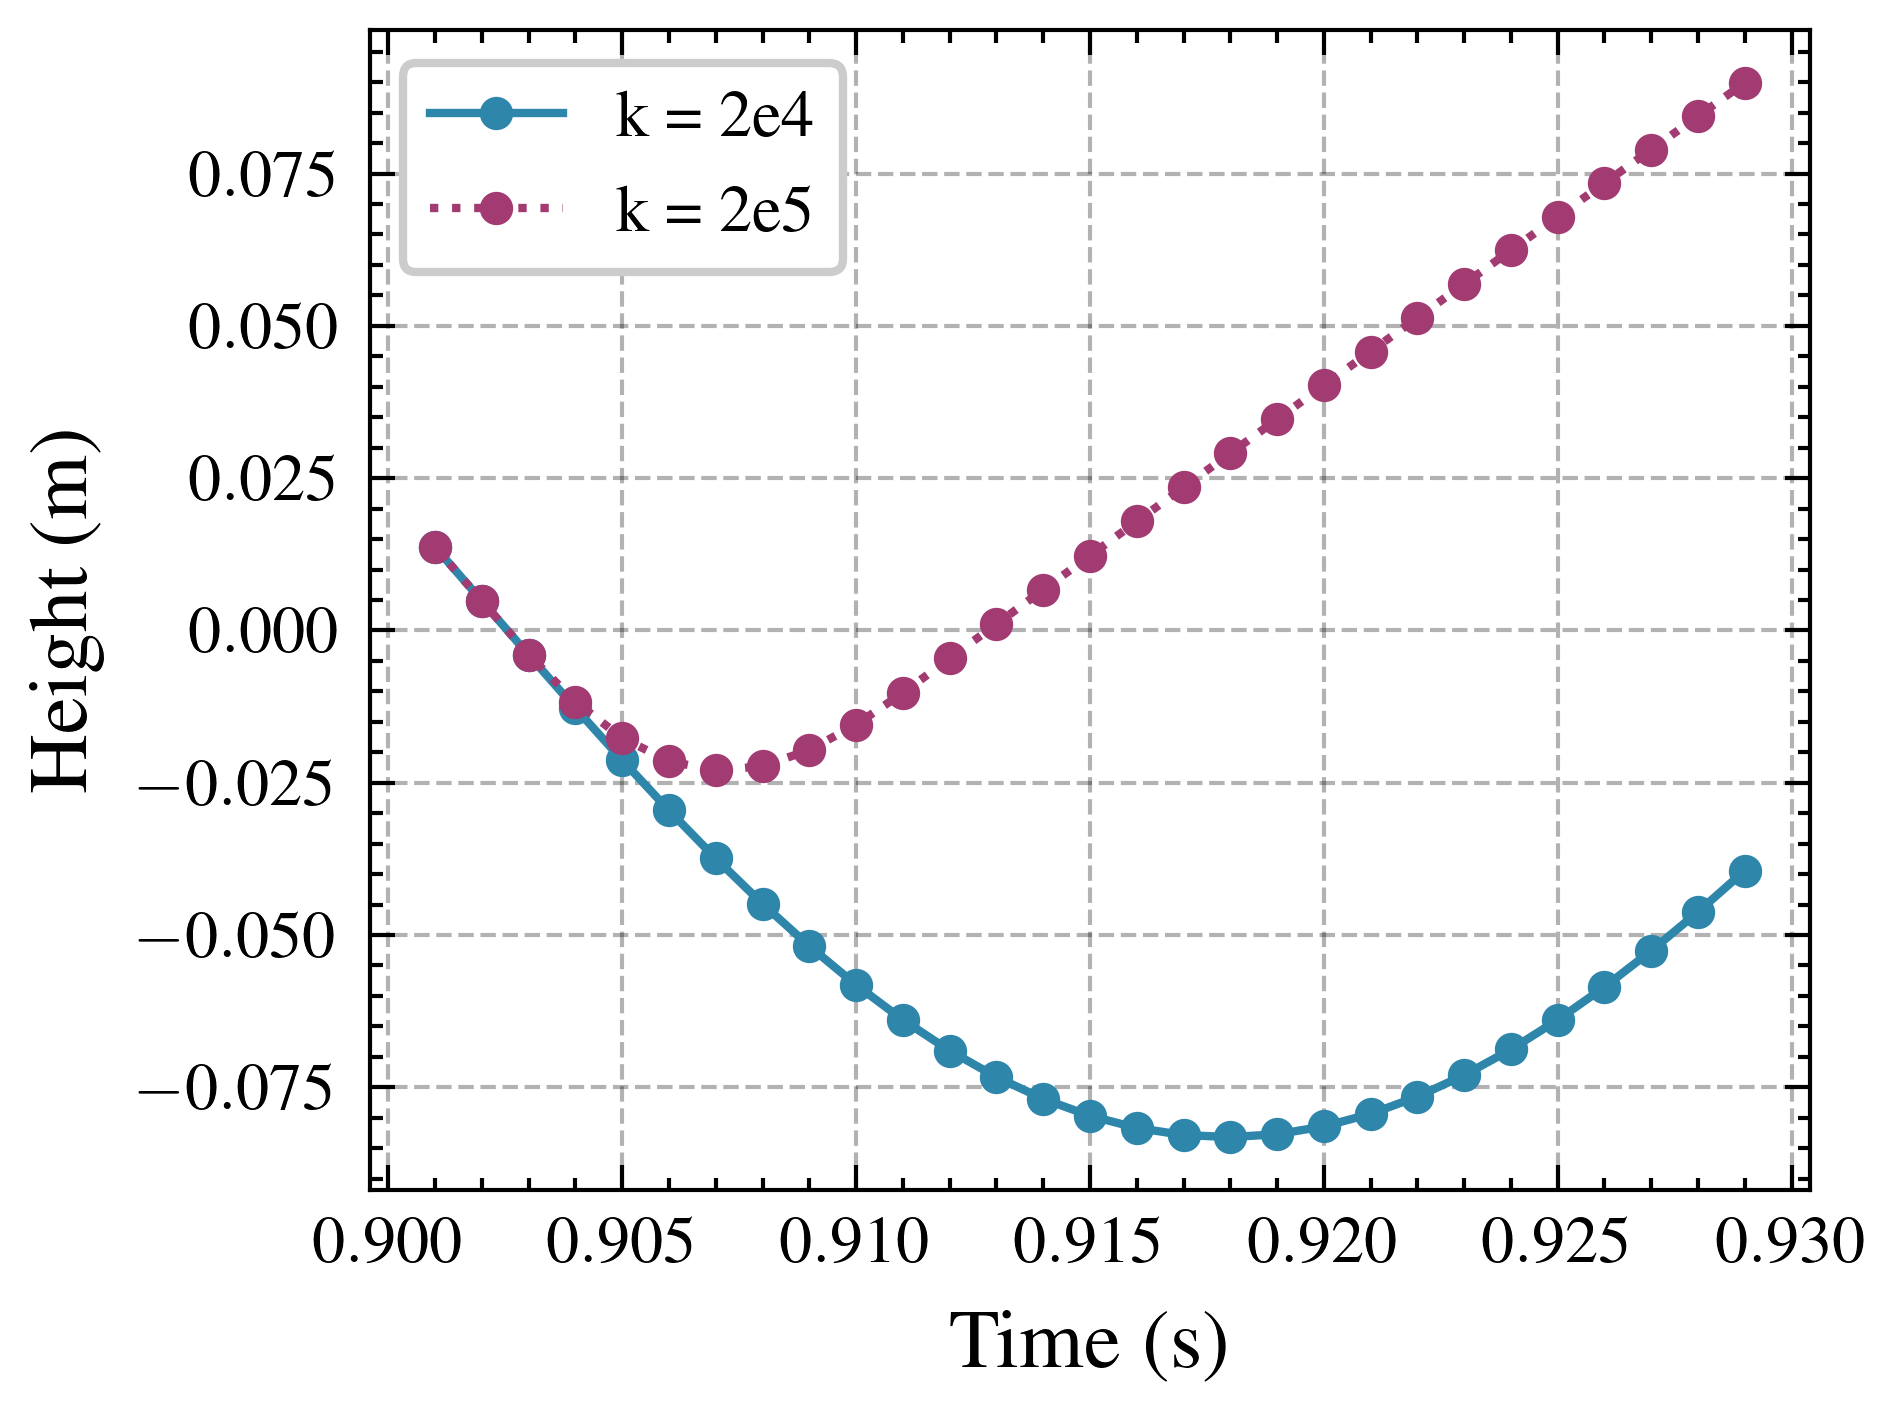

In [ ]:
# 绘制高度曲线
# plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    # 选择第一次接触地面附近的数据作图
    time = result['time'][901:930]
    height = result['height'][901:930]
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             marker='o', markersize=3,
             label=f"k = {simple_sci_format(rest_val)}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
# plt.legend(framealpha=0.9, loc="upper left")
plt.legend(loc="best", fontsize=8)
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
plt.title('First rebound in PyBullet (close-up view)')
# plt.ylim(bottom=-0.2, top=4.8)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()
for i, result in enumerate(all_results):
    # 选择第一次接触地面附近的数据作图
    time = result['time'][901:930]
    height = result['height'][901:930]
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             marker='o', markersize=3,
             label=f"k = {simple_sci_format(rest_val)}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
# plt.legend(framealpha=0.9, loc="upper left")
plt.legend(loc="best", fontsize=8)
plt.xlabel('Time (s)', fontsize=10)
plt.ylabel('Height (m)', fontsize=10)
# plt.title('First rebound in PyBullet (close-up view)')
# plt.ylim(bottom=-0.2, top=4.8)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_bullet_soft_zoomed.pdf", format="pdf", dpi=600, bbox_inches='tight')
# plt.show()
plt.close()

In [42]:
import pybullet as p
import numpy as np
import matplotlib.pyplot as plt

# ================== 仿真参数 ==================
restitution_list = [1.0]      # 不同的恢复系数
gravity = -9.81                     # 重力加速度 (m/s²)
timestep = 0.001                    # 仿真步长 (s)
sim_duration = 4.0                   # 仿真时长 (s)
num_steps = int(sim_duration / timestep)

radius = 0.5
mass = 1.0
init_height = 4.5      # 球心初始高度

all_results = []

for rest_idx, rest_val in enumerate(restitution_list):
    print(f"运行仿真 {rest_idx+1}, 恢复系数 = {rest_val}")

    # 连接物理引擎
    p.connect(p.DIRECT)
    p.setGravity(0, 0, gravity)
    p.setTimeStep(timestep)

    # ---------- 关键优化参数 ----------
    # p.setPhysicsEngineParameter(useSplitImpulse=True)       # 启用分离脉冲解决穿透
    # p.setPhysicsEngineParameter(numSolverIterations=300)    # 提高迭代次数（可更高）
    
    # 彻底杜绝惩罚力补充能量：
    p.setPhysicsEngineParameter(
        contactERP=0.0,                   # 【关键】把接触穿透的惩罚力设为0，杜绝能量注入
        # restitutionVelocityThreshold=0.0, # 确保恢复系数在任何微小速度下都生效
        # contactBreakingThreshold=0.001 
    )
    # 加载地面
    import pybullet_data
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")

    # 创建小球
    col_sphere = p.createCollisionShape(p.GEOM_SPHERE, radius=radius)
    vis_sphere = p.createVisualShape(p.GEOM_SPHERE, radius=radius, rgbaColor=[1, 0, 0, 1])
    sphere_id = p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=col_sphere,
        baseVisualShapeIndex=vis_sphere,
        basePosition=[0, 0, init_height]
    )

    # ---------- 接触刚度和阻尼设置 ----------
    # 设置极高的接触刚度，极低的接触阻尼，使接触更接近理想弹性
    p.changeDynamics(plane_id, -1, restitution=1.0)
    p.changeDynamics(sphere_id, -1, restitution=rest_val)
    p.changeDynamics(sphere_id, -1, linearDamping=0, angularDamping=0)
    # p.changeDynamics(plane_id, -1, contactStiffness=2e8, contactDamping=0)
    # p.changeDynamics(sphere_id, -1, contactStiffness=2e8, contactDamping=0)
    # 打印当前参数，确认设置生效
    print(p.getPhysicsEngineParameters())

    # 记录数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    for i in range(num_steps):
        p.stepSimulation()
        time_points[i] = i * timestep
        pos, _ = p.getBasePositionAndOrientation(sphere_id)
        vel, _ = p.getBaseVelocity(sphere_id)
        height_points[i] = pos[2] - radius
        velocity_points[i] = vel[2]

    p.disconnect()

    all_results.append({
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'restitution': rest_val
    })
    print(f"仿真 {rest_idx+1} 完成")

# 绘制结果（略，同之前）

运行仿真 1, 恢复系数 = 1.0
{'fixedTimeStep': 0.001, 'numSubSteps': 0, 'numSolverIterations': 50, 'useRealTimeSimulation': 0, 'gravityAccelerationX': 0.0, 'gravityAccelerationY': 0.0, 'gravityAccelerationZ': -9.81, 'numNonContactInnerIterations': 1}
仿真 1 完成


恢复系数 e=1.0 的峰值时间和高度：
  时间: 1.806 s, 高度: 4.00886824 m
  时间: 3.616 s, 高度: 4.01774629 m


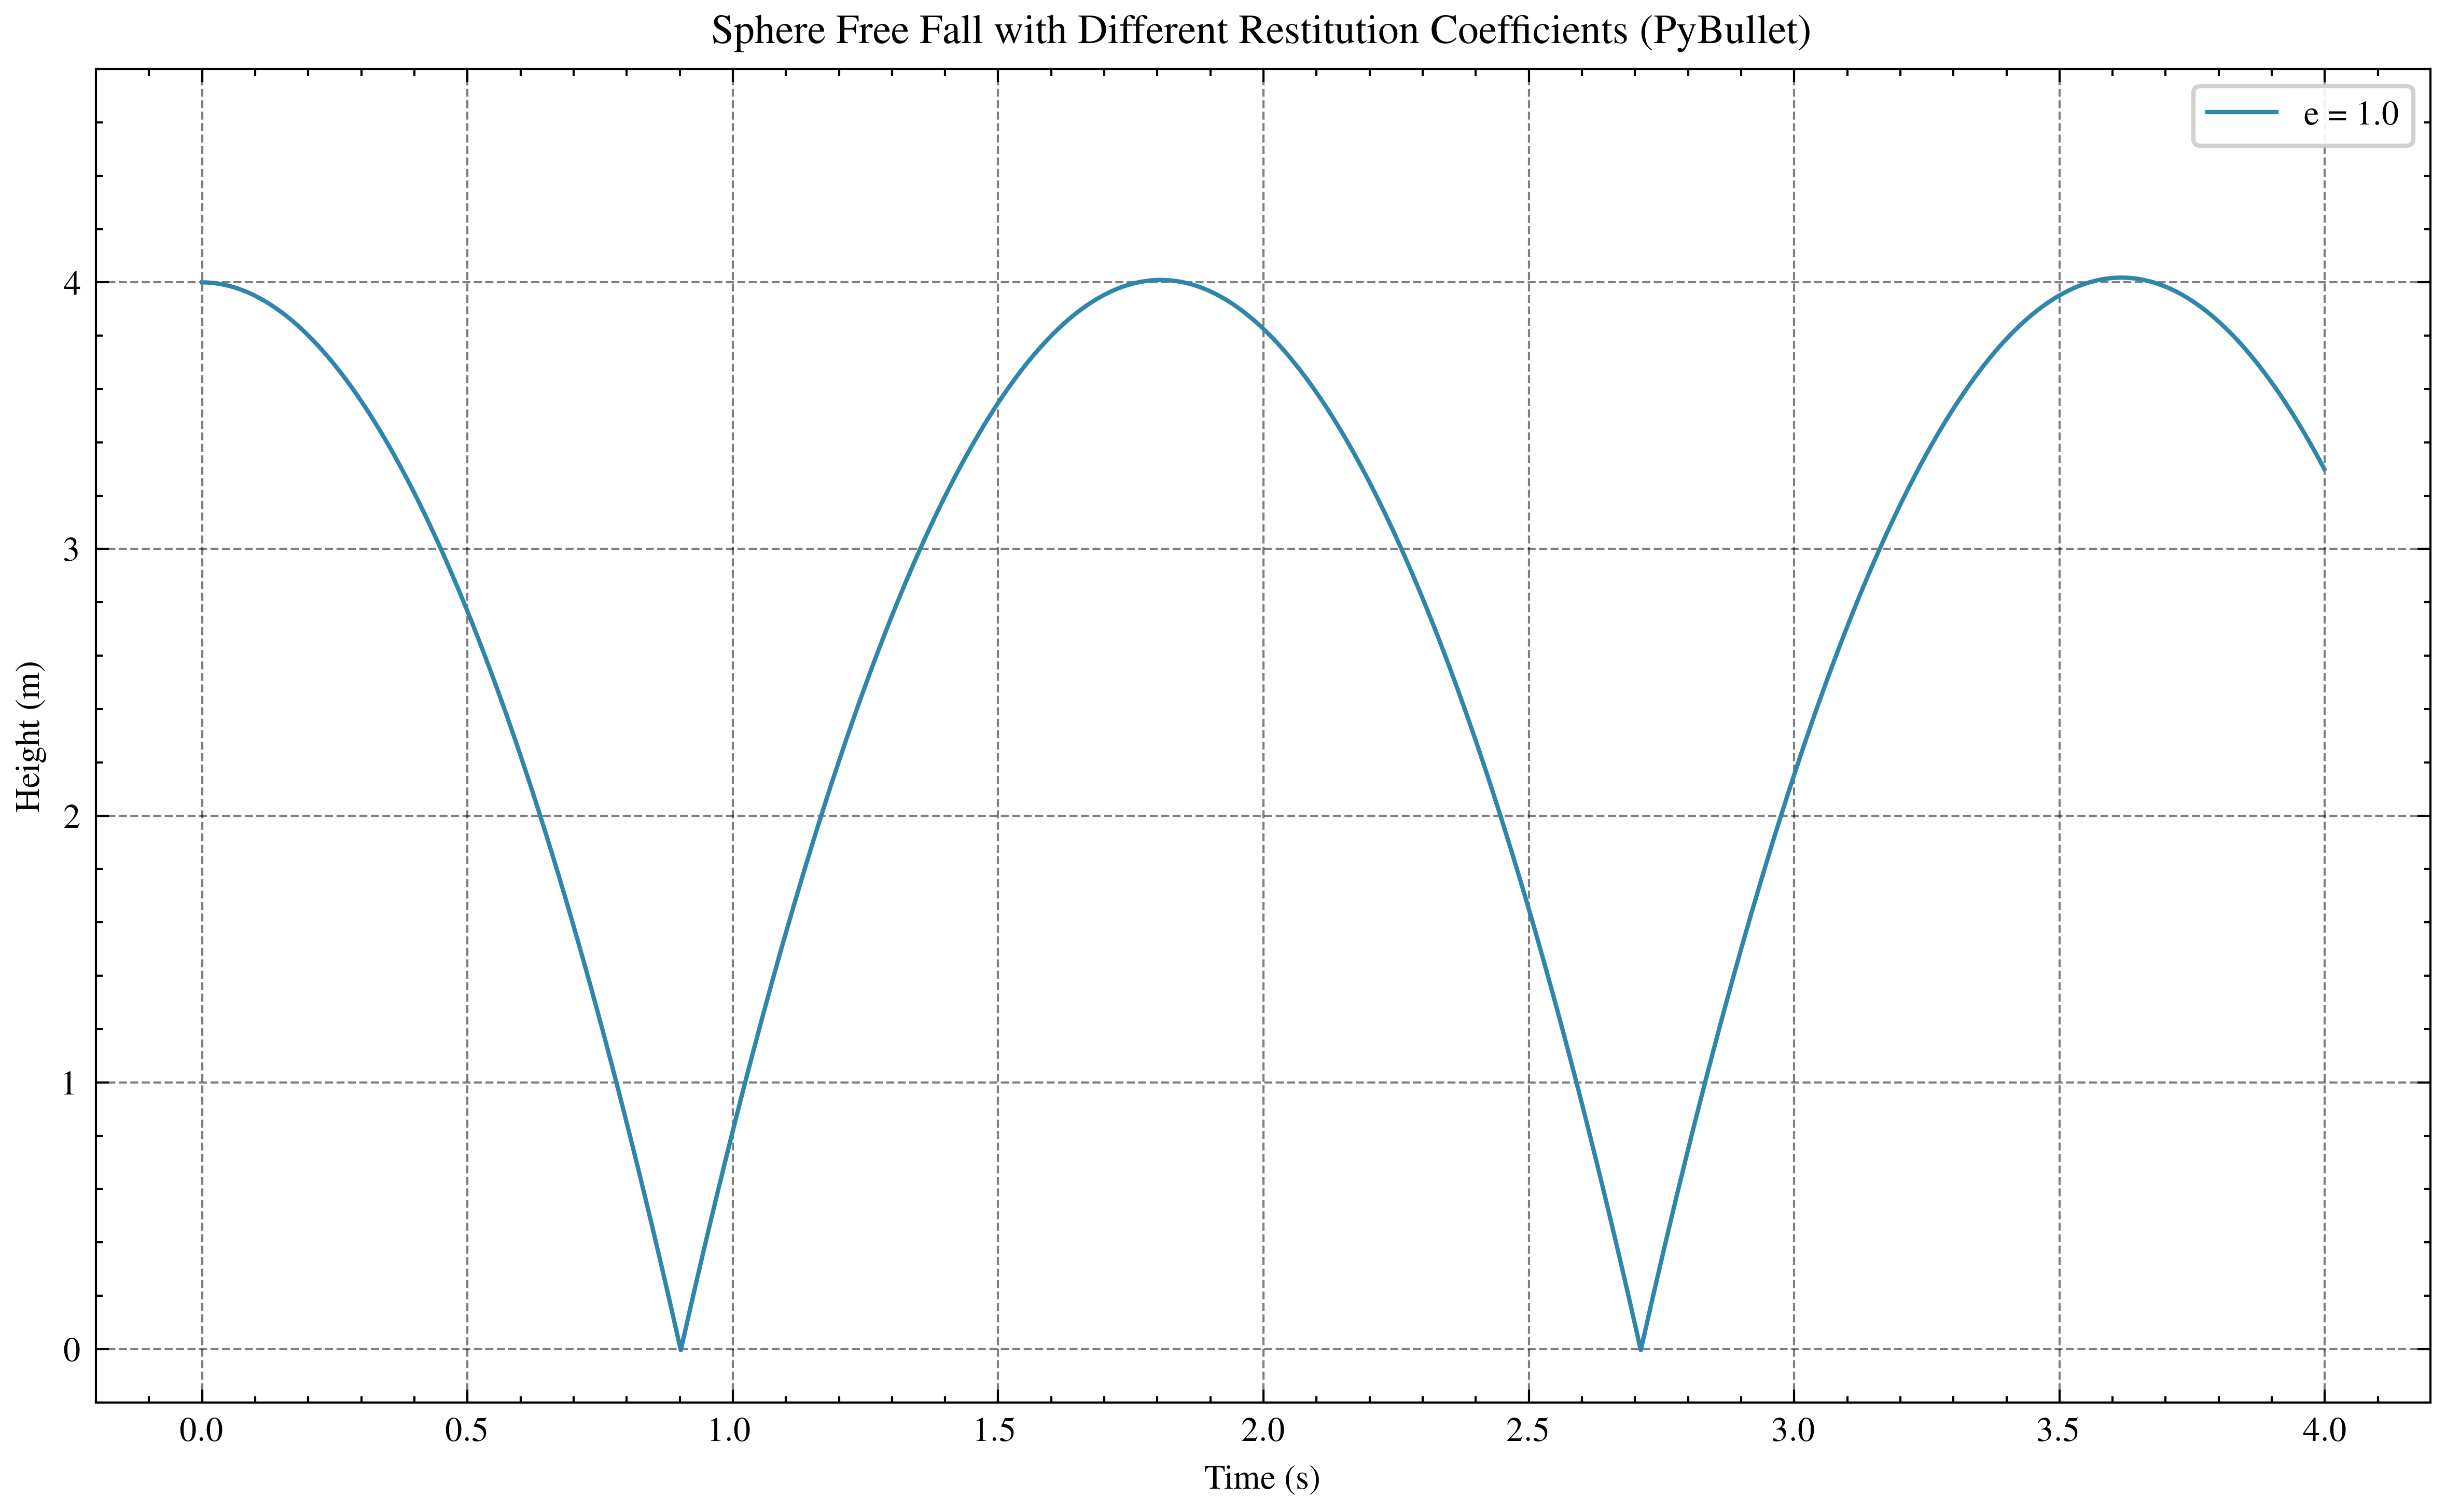

In [43]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# ================== 绘制结果 ==================
# 设置字体（避免中文乱码，若无中文字体可注释）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['science', 'ieee', 'grid'])

# 定义线型和颜色
linestyles = ["-", ":", "--", "-."]
scientific_colors = [
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
    '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
]

# get max height for every bounce
for result in all_results:
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    # 找到所有峰值（反弹最高点）
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(height)
    peak_times = time[peaks]
    peak_heights = height[peaks]

    print(f"恢复系数 e={rest_val} 的峰值时间和高度：")
    for t, h in zip(peak_times, peak_heights):
        print(f"  时间: {t:.3f} s, 高度: {h} m")

# 绘制高度曲线
plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    time = result['time']
    height = result['height']
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])

# 添加注释（示例：针对 e=1.1 可能出现的能量增加现象，可自行调整）
# 这里简单演示如何添加文字标注
if 1.1 in restitution_list:
    idx = restitution_list.index(1.1)
    # 找到第一次反弹后的某个点作为标注位置
    time_data = all_results[idx]['time']
    height_data = all_results[idx]['height']
    # 寻找第二个峰值附近（约 2.5 s）
    t_mark = 2.5
    i_mark = np.argmin(np.abs(time_data - t_mark))
    h_mark = height_data[i_mark]
    plt.annotate('Energy gain\n(e > 1)', xy=(t_mark, h_mark),
                 xytext=(t_mark+0.5, h_mark+0.5),
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
                 fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="none", alpha=0.7))

plt.legend(framealpha=0.9, loc="upper right")
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Sphere Free Fall with Different Restitution Coefficients (PyBullet)')
plt.ylim(bottom=-0.2, top=4.8)
plt.tight_layout()
plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.show()

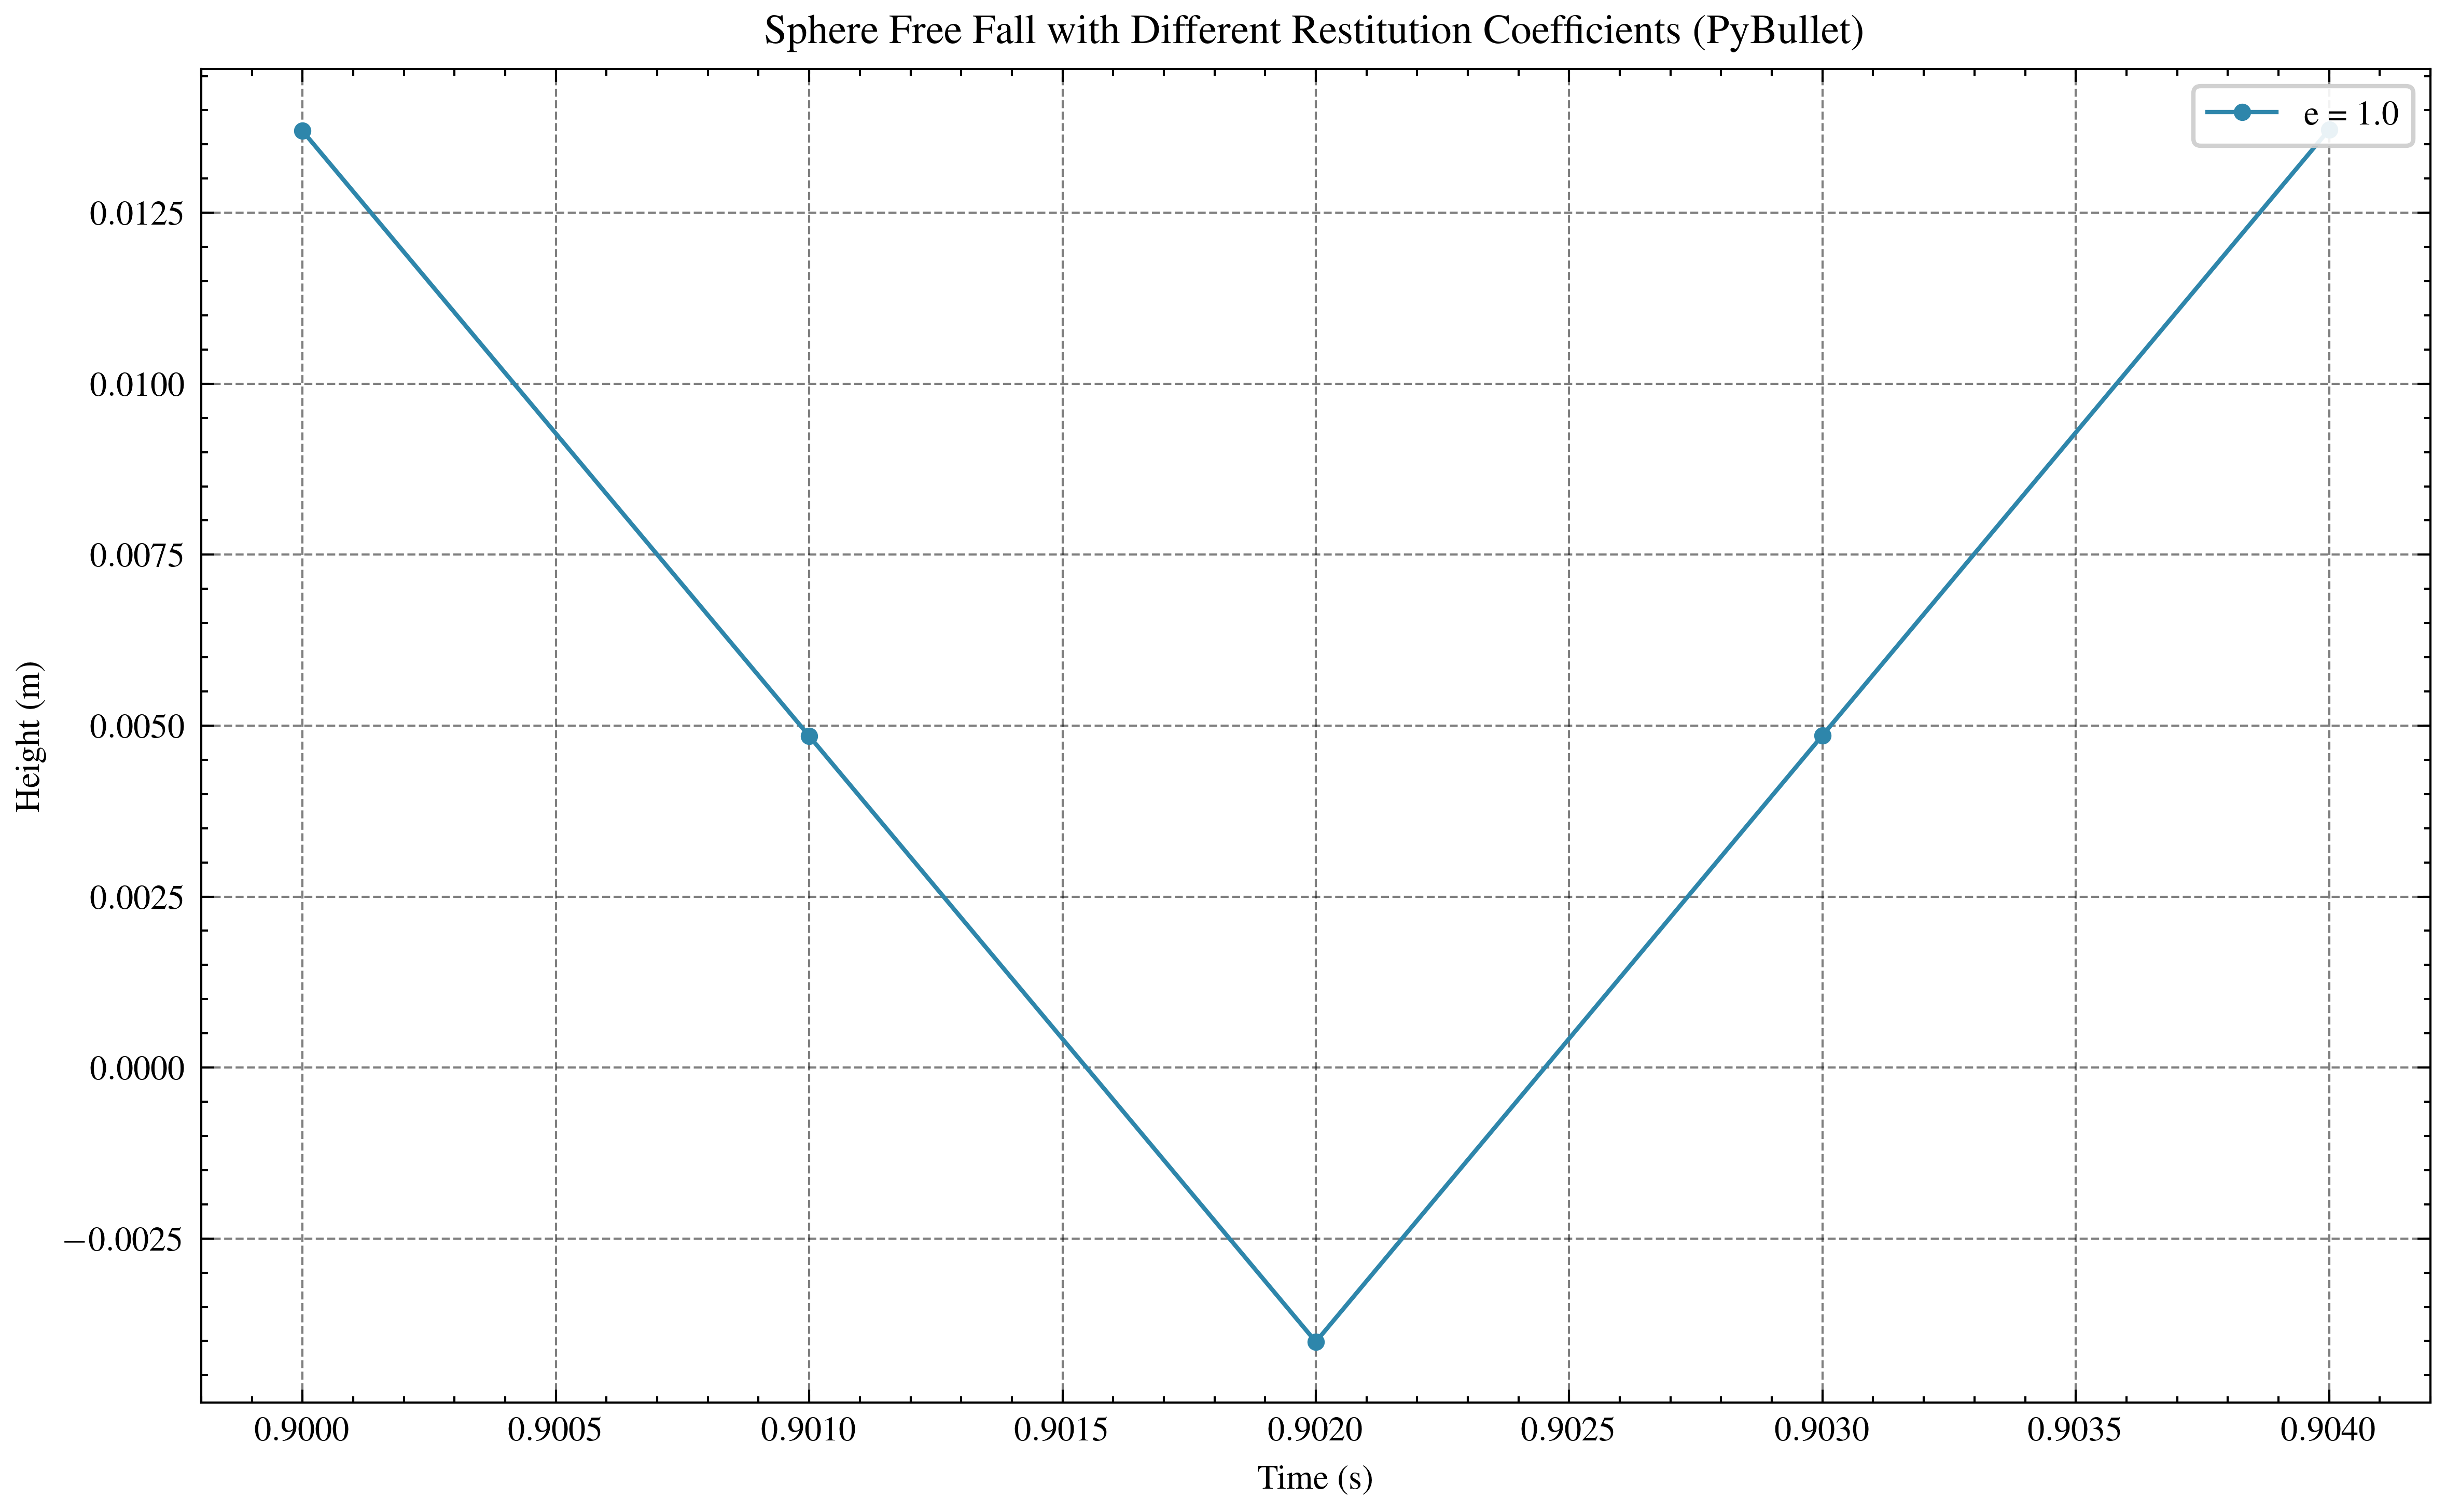

In [45]:
# 绘制高度曲线
plt.figure(figsize=(8, 5))
for i, result in enumerate(all_results):
    # 选择第一次接触地面附近的数据作图
    time = result['time'][900:905]
    height = result['height'][900:905]
    rest_val = result['restitution']

    plt.plot(time, height, linewidth=1,
             marker='o', markersize=3,
             label=f"e = {rest_val}",
             color=scientific_colors[i % len(scientific_colors)],
             linestyle=linestyles[i % len(linestyles)])
plt.legend(framealpha=0.9, loc="upper right")
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Sphere Free Fall with Different Restitution Coefficients (PyBullet)')
# plt.ylim(bottom=-0.2, top=4.8)
plt.tight_layout()
# plt.savefig("sphere_free_fall_pybullet.pdf", format="pdf", dpi=600, bbox_inches='tight')
plt.show()

测试高刚度接触...
力  9.0 N -> 最大高度 -0.000 m
力  9.1 N -> 最大高度 -0.000 m
力  9.2 N -> 最大高度 -0.000 m
力  9.3 N -> 最大高度 -0.000 m
力  9.4 N -> 最大高度 -0.000 m
力  9.5 N -> 最大高度 -0.000 m
力  9.6 N -> 最大高度 -0.000 m
力  9.7 N -> 最大高度 -0.000 m
力  9.8 N -> 最大高度 -0.000 m
力  9.9 N -> 最大高度 0.007 m
力 10.0 N -> 最大高度 0.015 m
力 10.1 N -> 最大高度 0.024 m
力 10.2 N -> 最大高度 0.032 m
力 10.3 N -> 最大高度 0.041 m
力 10.4 N -> 最大高度 0.050 m
力 10.5 N -> 最大高度 0.059 m
力 10.6 N -> 最大高度 0.068 m
力 10.7 N -> 最大高度 0.078 m
力 10.8 N -> 最大高度 0.087 m
力 10.9 N -> 最大高度 0.097 m
力 11.0 N -> 最大高度 0.107 m
力 11.1 N -> 最大高度 0.117 m
力 11.2 N -> 最大高度 0.127 m
力 11.3 N -> 最大高度 0.137 m
力 11.4 N -> 最大高度 0.148 m
力 11.5 N -> 最大高度 0.158 m
力 11.6 N -> 最大高度 0.169 m
力 11.7 N -> 最大高度 0.180 m
力 11.8 N -> 最大高度 0.191 m
力 11.9 N -> 最大高度 0.203 m
力 12.0 N -> 最大高度 0.214 m

测试低刚度接触...
力  9.0 N -> 最大高度 -0.000 m
力  9.1 N -> 最大高度 -0.000 m
力  9.2 N -> 最大高度 -0.000 m
力  9.3 N -> 最大高度 -0.000 m
力  9.4 N -> 最大高度 -0.000 m
力  9.5 N -> 最大高度 -0.000 m
力  9.6 N -> 最大高度 -0.000 m
力  9.7 N ->

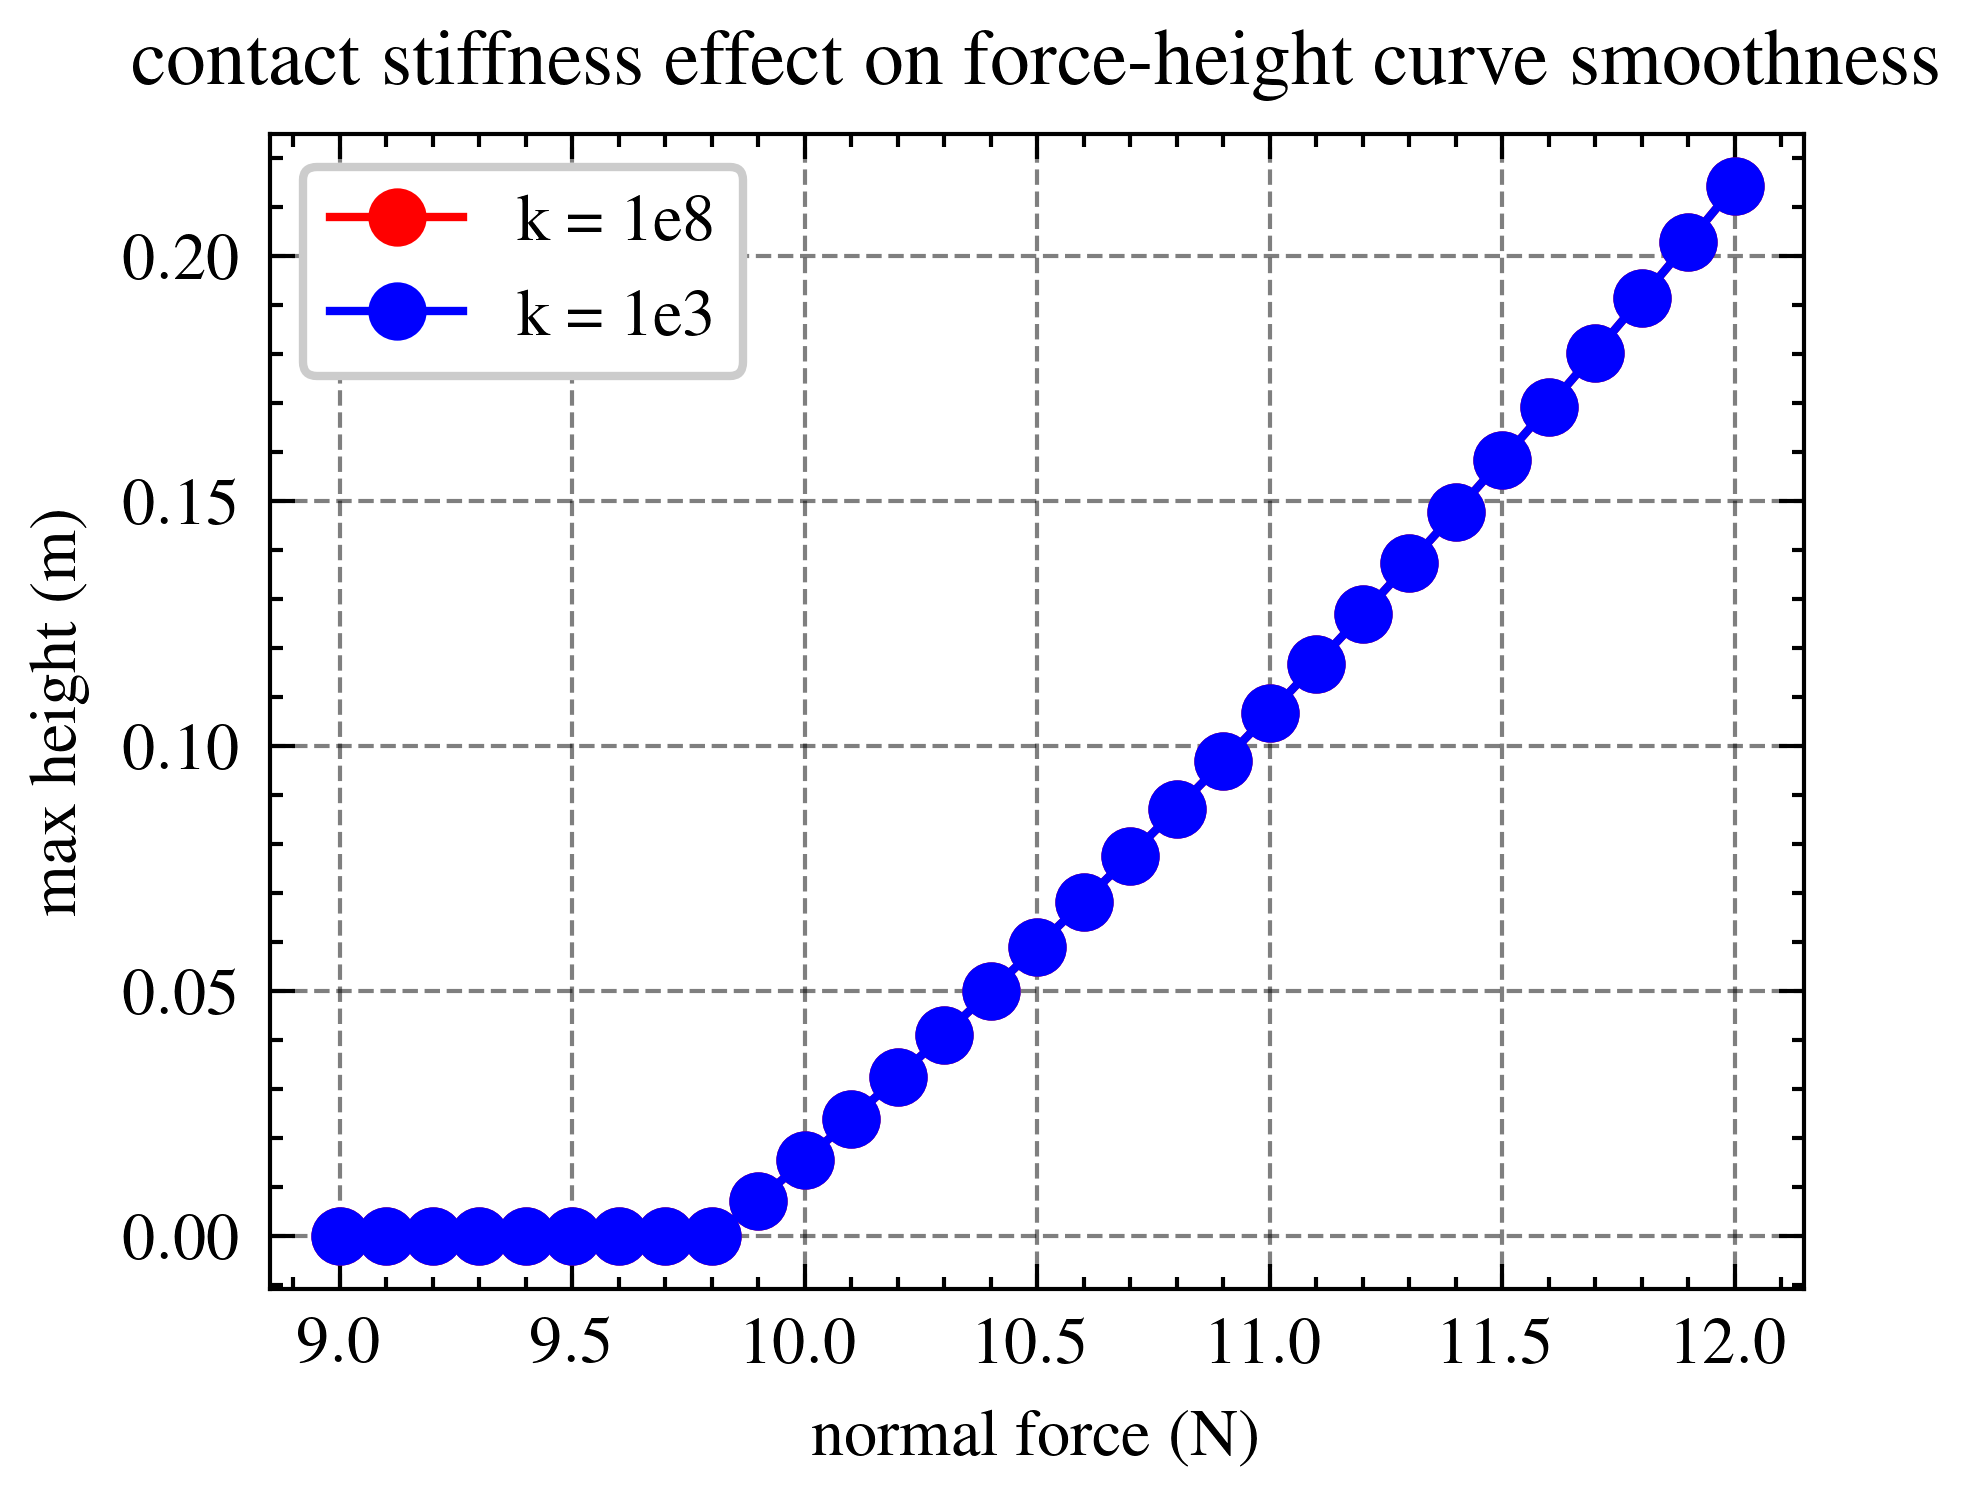

In [145]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
radius = 0.2
mass = 1.0
def run_simulation(force, stiffness, damping, dt=0.001, sim_time=1.0, force_duration=0.1):
    p.setTimeStep(dt)
    """
    执行一次仿真：球体初始轻微穿透地面，施加恒定向上力 force 持续 force_duration 秒，
    记录球体达到的最大高度。
    """
    # 重置球体位置和速度：半径0.2，中心z=0.2 => 球底z=0，穿透0.2
    p.resetBasePositionAndOrientation(sphere_id, [0, 0, 0.2], [0, 0, 0, 1])
    p.resetBaseVelocity(sphere_id, [0, 0, 0], [0, 0, 0])

    # 更新接触刚度（需同时设置地面和球体）
    p.changeDynamics(plane_id, -1, contactStiffness=stiffness, contactDamping=damping)
    p.changeDynamics(sphere_id, -1, contactStiffness=stiffness, contactDamping=damping)
    p.changeDynamics(sphere_id, -1, linearDamping=0, angularDamping=0)

    max_height = -1  # 初始高度
    time_force_end = force_duration

    for step in range(int(sim_time / dt)):
        t = step * dt
        if t < time_force_end:
            # 在球心施加向上的力
            p.applyExternalForce(sphere_id, -1, forceObj=[0, 0, force],
                                 posObj=[0, 0, 0.2], flags=p.LINK_FRAME)
        p.stepSimulation()
        pos, _ = p.getBasePositionAndOrientation(sphere_id)
        current_height = pos[2] - radius  # 球心高度减去半径得到球底高度
        if current_height > max_height:
            max_height = current_height

    return max_height


# -------------------- 初始化仿真环境 --------------------
physics_client = p.connect(p.DIRECT)  # 无图形界面，加快计算
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

# 创建地面
plane_id = p.loadURDF("plane.urdf")

# 创建球体（半径0.2m，质量1kg）
sphere_radius = 0.2
sphere_mass = 1.0
sphere_collision = p.createCollisionShape(p.GEOM_SPHERE, radius=sphere_radius)
sphere_visual = p.createVisualShape(p.GEOM_SPHERE, radius=sphere_radius, rgbaColor=[1, 0, 0, 1])
sphere_id = p.createMultiBody(baseMass=sphere_mass,
                              baseCollisionShapeIndex=sphere_collision,
                              baseVisualShapeIndex=sphere_visual,
                              basePosition=[0, 0, 0.2])  # 球底穿透地面0.2m

# -------------------- 扫描参数设置 --------------------
# force_range = np.linspace(0, 20, 51)  # 加密采样点，比如 51 个点
force_range = np.linspace(9, 12, 31)  # 9~12 N，31个点
# 高刚度（近似硬接触）
stiffness_high = 1e8
damping_high = 0
# 低刚度（软接触）
stiffness_low = 1e3
damping_low = 0

heights_high = []
heights_low = []
# 高刚度测试
print("测试高刚度接触...")
for f in force_range:
    h = run_simulation(f, stiffness_high, damping_high, force_duration=0.4)
    heights_high.append(h)
    print(f"力 {f:4.1f} N -> 最大高度 {h:.3f} m")

# 低刚度测试
print("\n测试低刚度接触...")
for f in force_range:
    h = run_simulation(f, stiffness_low, damping_low, force_duration=0.4)
    heights_low.append(h)
    print(f"力 {f:4.1f} N -> 最大高度 {h:.3f} m")
print(heights_high)
print(heights_low)

p.disconnect()

# -------------------- 绘制结果 --------------------
plt.plot(force_range, heights_high, 'r-o', label='k = 1e8')
plt.plot(force_range, heights_low,  'b-o', label='k = 1e3')
plt.xlabel('normal force (N)')
plt.ylabel('max height (m)')
# plt.title('接触刚度对推力-高度曲线平滑性的影响')
plt.title('contact stiffness effect on force-height curve smoothness')
plt.legend()
plt.grid(True)
plt.show()

测试高刚度接触...
力  9.1 N -> slope 0.00000 m
力  9.1 N -> slope 0.00000 m
力  9.2 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.6 N -> slope 0.00000 m
力  9.6 N -> slope 0.00000 m
力  9.8 N -> slope 0.00000 m
力  9.9 N -> slope 0.07267 m
力  9.9 N -> slope 0.08228 m
力 10.1 N -> slope 0.08391 m
力 10.1 N -> slope 0.08554 m
力 10.2 N -> slope 0.08717 m
力 10.4 N -> slope 0.08881 m
力 10.4 N -> slope 0.09044 m
力 10.6 N -> slope 0.09207 m
力 10.6 N -> slope 0.09370 m
力 10.8 N -> slope 0.09533 m
力 10.9 N -> slope 0.09696 m
力 10.9 N -> slope 0.09859 m
力 11.1 N -> slope 0.10022 m
力 11.1 N -> slope 0.10185 m
力 11.2 N -> slope 0.10348 m
力 11.4 N -> slope 0.10511 m
力 11.4 N -> slope 0.10675 m
力 11.6 N -> slope 0.10838 m
力 11.6 N -> slope 0.11001 m
力 11.8 N -> slope 0.11164 m
力 11.9 N -> slope 0.11327 m
力 11.9 N -> slope 0.11491 m
测试低刚度接触...
力  9.1 N -> slope 0.00000 m
力  9.1 N -> slope 0.00000 m
力  9.2 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 

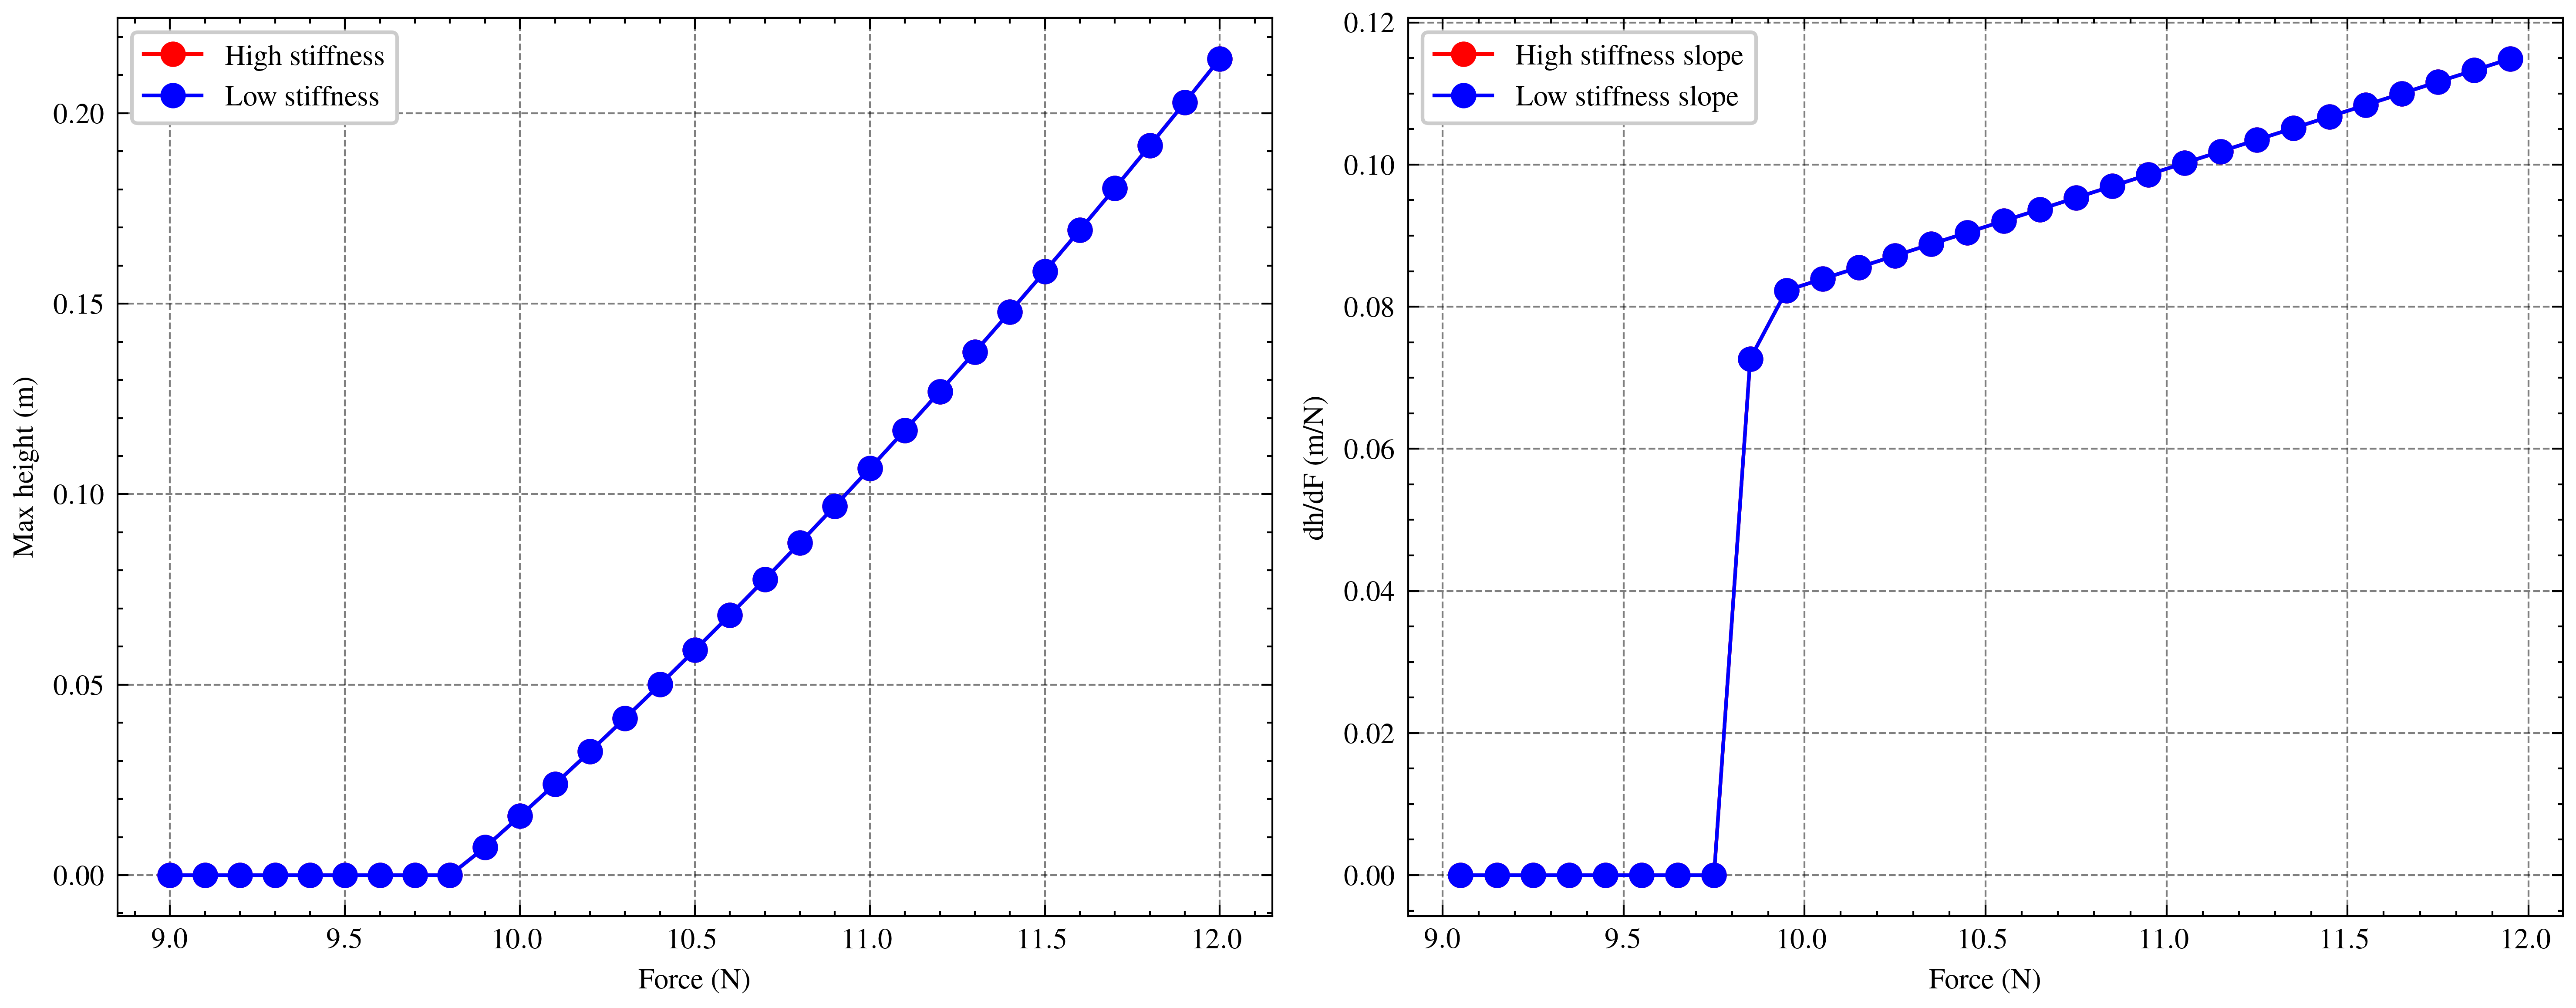

In [146]:
# 计算一阶差分近似导数
diff_high = np.diff(heights_high) / np.diff(force_range)
diff_low  = np.diff(heights_low)  / np.diff(force_range)
force_mid = (force_range[:-1] + force_range[1:]) / 2

# 高刚度测试
print("测试高刚度接触...")
for i in range(len(force_mid)):
    print(f"力 {force_mid[i]:4.1f} N -> slope {diff_high[i]:.5f} m")

# 低刚度测试
print("测试低刚度接触...")
for i in range(len(force_mid)):
    print(f"力 {force_mid[i]:4.1f} N -> slope {diff_low[i]:.5f} m")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(force_range, heights_high, 'r-o', label='High stiffness')
plt.plot(force_range, heights_low,  'b-o', label='Low stiffness')
plt.xlabel('Force (N)'); plt.ylabel('Max height (m)')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(force_mid, diff_high, 'r-o', label='High stiffness slope')
plt.plot(force_mid, diff_low,  'b-o', label='Low stiffness slope')
plt.xlabel('Force (N)'); plt.ylabel('dh/dF (m/N)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

测试硬接触模式（分离脉冲+长作用时间）...
力  9.00 N -> 最大高度 0.000000 m
力  9.10 N -> 最大高度 0.000000 m
力  9.20 N -> 最大高度 0.000000 m
力  9.30 N -> 最大高度 0.000000 m
力  9.40 N -> 最大高度 0.000000 m
力  9.50 N -> 最大高度 0.000000 m
力  9.60 N -> 最大高度 0.000000 m
力  9.70 N -> 最大高度 0.000000 m
力  9.80 N -> 最大高度 0.000000 m
力  9.90 N -> 最大高度 0.007818 m
力 10.00 N -> 最大高度 0.015495 m
力 10.10 N -> 最大高度 0.023887 m
力 10.20 N -> 最大高度 0.032441 m
力 10.30 N -> 最大高度 0.041158 m
力 10.40 N -> 最大高度 0.050039 m
力 10.50 N -> 最大高度 0.059083 m
力 10.60 N -> 最大高度 0.068290 m
力 10.70 N -> 最大高度 0.077661 m
力 10.80 N -> 最大高度 0.087194 m
力 10.90 N -> 最大高度 0.096890 m
力 11.00 N -> 最大高度 0.106749 m
力 11.10 N -> 最大高度 0.116772 m
力 11.20 N -> 最大高度 0.126957 m
力 11.30 N -> 最大高度 0.137306 m
力 11.40 N -> 最大高度 0.147817 m
力 11.50 N -> 最大高度 0.158492 m
力 11.60 N -> 最大高度 0.169329 m
力 11.70 N -> 最大高度 0.180331 m
力 11.80 N -> 最大高度 0.191495 m
力 11.90 N -> 最大高度 0.202822 m
力 12.00 N -> 最大高度 0.214313 m


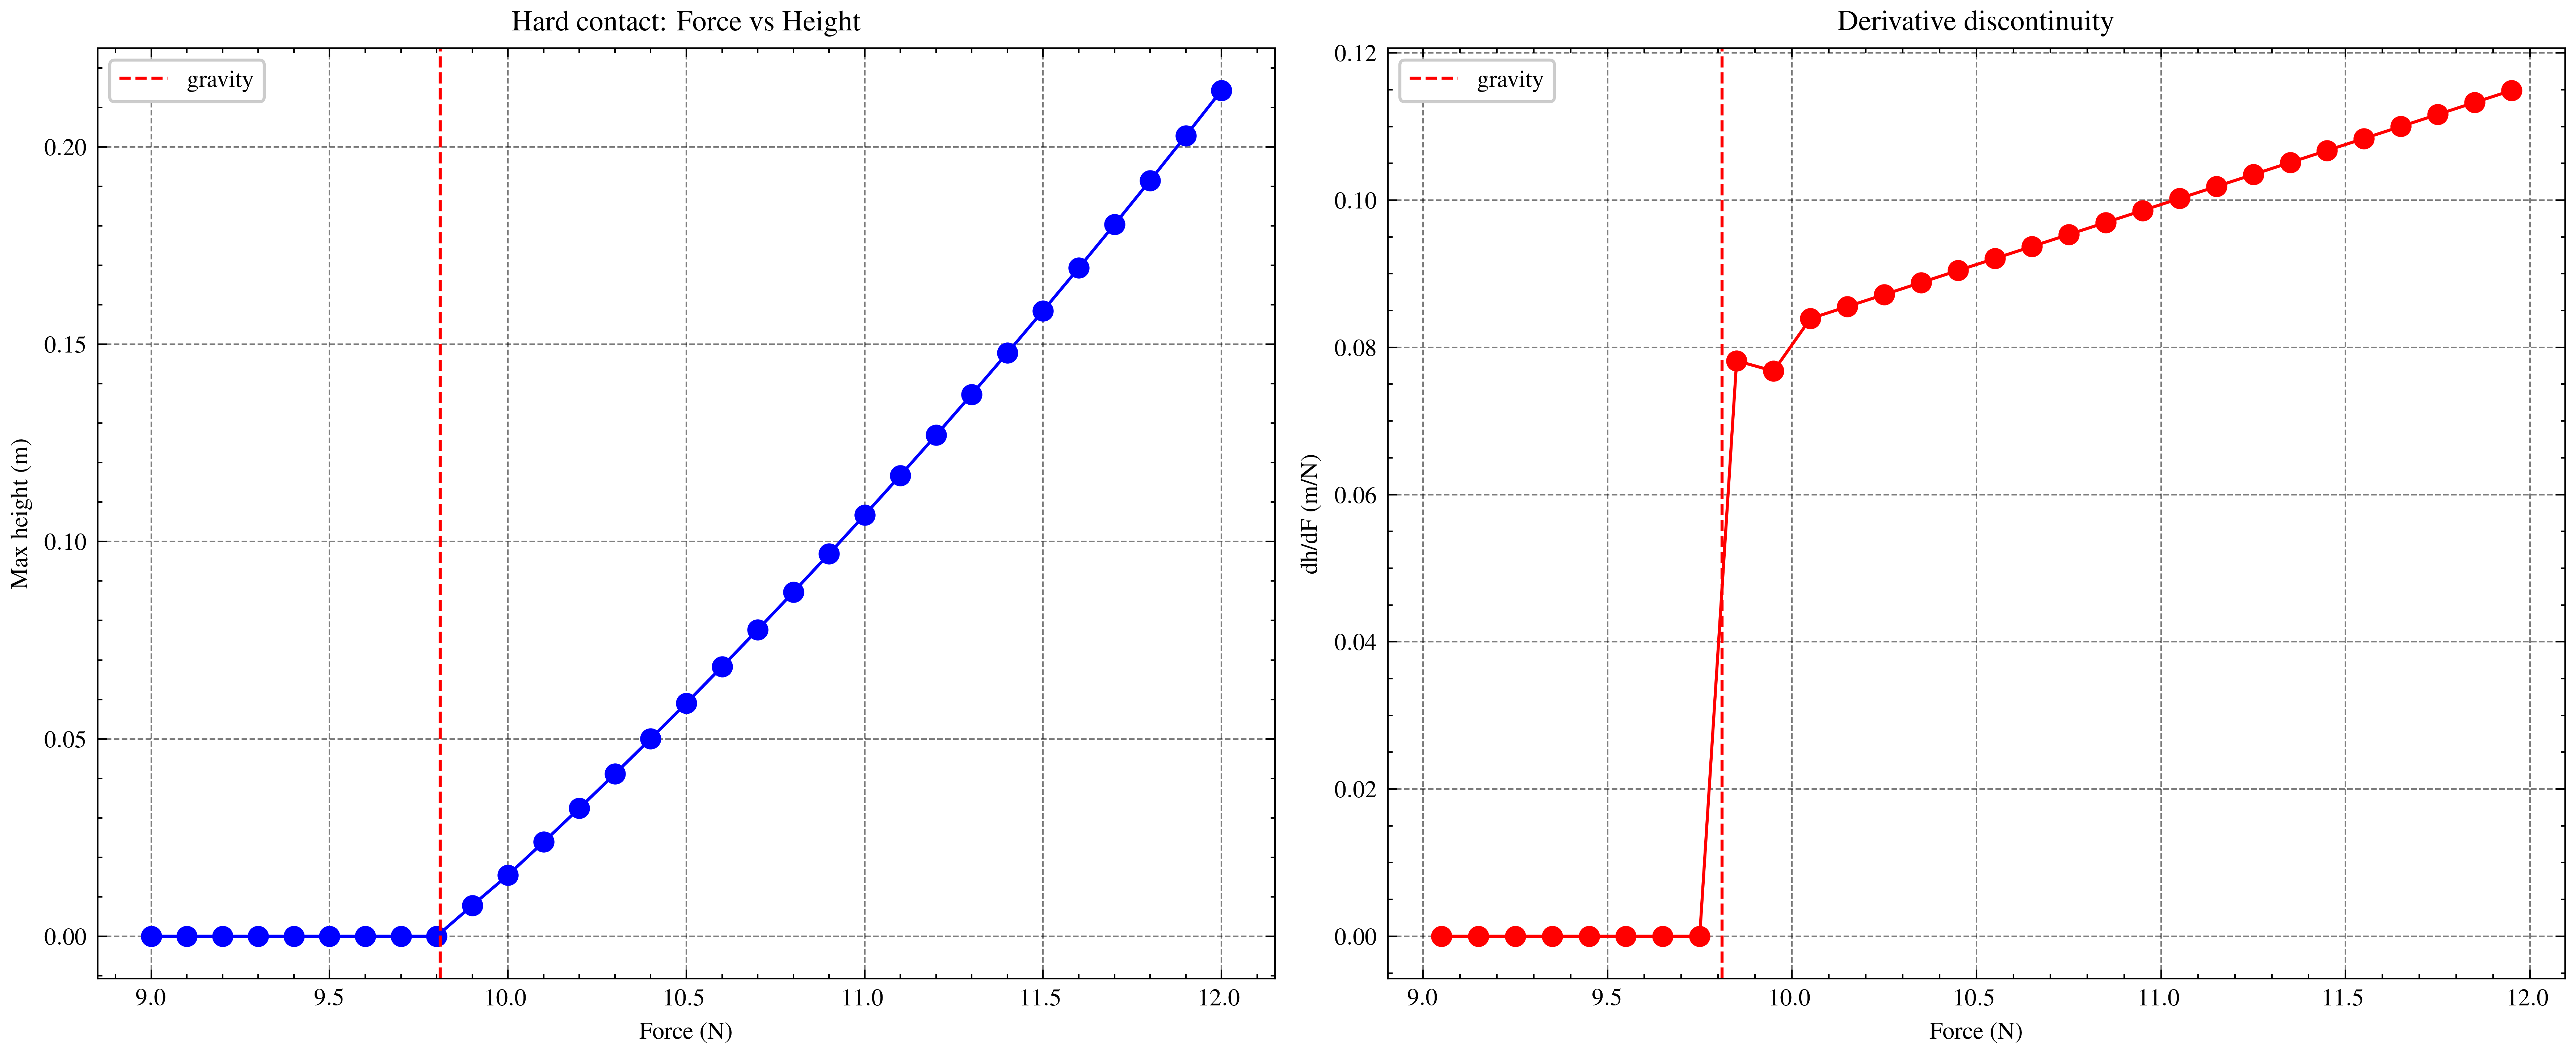

In [27]:
import pybullet as p
import numpy as np
import matplotlib.pyplot as plt

def run_hard_contact_simulation(force, rest_coeff=1.0, dt=0.001, sim_time=1.0, force_duration=1.0):
    p.connect(p.DIRECT)
    p.setGravity(0, 0, -9.81)
    p.setTimeStep(dt)

    # 启用分离脉冲，提高求解精度
    p.setPhysicsEngineParameter(
        # useSplitImpulse=False,
        # numSolverIterations=1000,
        # contactBreakingThreshold=1e-9,
        # erp=0.0,
        contactERP=0.0,
        # frictionERP=0.0
    )

    import pybullet_data
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")

    radius = 0.2
    mass = 1.0
    col_sphere = p.createCollisionShape(p.GEOM_SPHERE, radius=radius)
    vis_sphere = p.createVisualShape(p.GEOM_SPHERE, radius=radius, rgbaColor=[1,0,0,1])
    sphere_id = p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=col_sphere,
        baseVisualShapeIndex=vis_sphere,
        basePosition=[0, 0, radius]  # 刚好接触
    )

    # 设置摩擦为0
    p.changeDynamics(sphere_id, -1, restitution=rest_coeff, lateralFriction=0,
                     spinningFriction=0, rollingFriction=0)
    p.changeDynamics(plane_id, -1, restitution=rest_coeff, lateralFriction=0,
                     spinningFriction=0, rollingFriction=0)
    p.changeDynamics(sphere_id, -1, linearDamping=0, angularDamping=0)

    max_height = 0
    time_force_end = force_duration

    for step in range(int(sim_time / dt)):
        t = step * dt
        if t < time_force_end:
            p.applyExternalForce(sphere_id, -1, forceObj=[0, 0, force],
                                 posObj=[0, 0, radius], flags=p.LINK_FRAME)
        p.stepSimulation()
        pos, _ = p.getBasePositionAndOrientation(sphere_id)
        current_height = pos[2] - radius
        if current_height > max_height:
            max_height = current_height

    p.disconnect()
    return max_height

# 在重力附近加密采样
force_range = np.linspace(9, 12, 31)  # 9~12 N，31个点
heights = []

print("测试硬接触模式（分离脉冲+长作用时间）...")
for f in force_range:
    h = run_hard_contact_simulation(f,rest_coeff=0.99, force_duration=0.4)
    heights.append(h)
    print(f"力 {f:5.2f} N -> 最大高度 {h:.6f} m")

# 计算差分斜率
force_mid = (force_range[:-1] + force_range[1:]) / 2
slopes = np.diff(heights) / np.diff(force_range)

# 绘图
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(force_range, heights, 'b-o')
plt.axvline(x=9.81, color='r', linestyle='--', label='gravity')
plt.xlabel('Force (N)'); plt.ylabel('Max height (m)')
plt.title('Hard contact: Force vs Height')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(force_mid, slopes, 'r-o')
plt.axvline(x=9.81, color='r', linestyle='--', label='gravity')
plt.xlabel('Force (N)'); plt.ylabel('dh/dF (m/N)')
plt.title('Derivative discontinuity')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

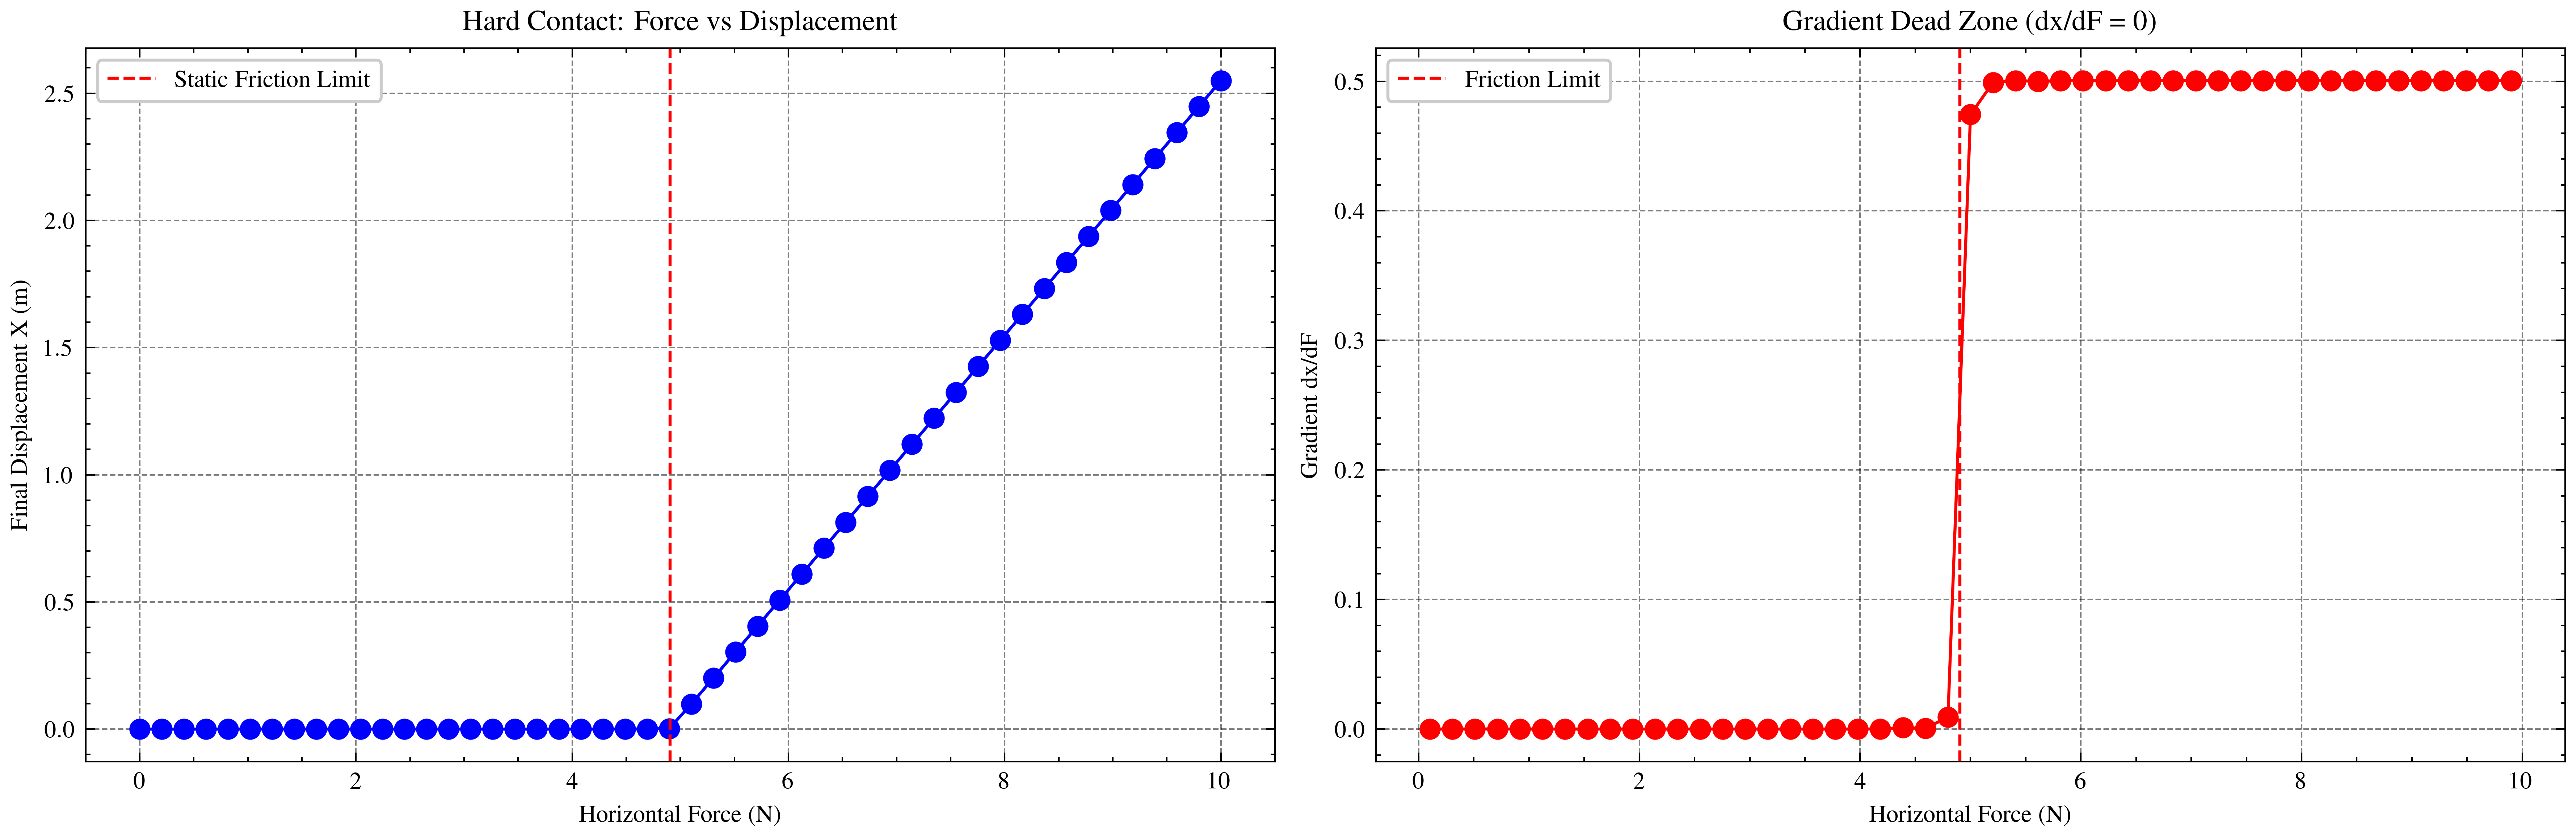

In [156]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt

def run_friction_push(force, dt=0.001, sim_time=1.0):
    p.connect(p.DIRECT)
    p.setGravity(0, 0, -9.81)
    p.setTimeStep(dt)
    
    # 使用纯硬约束
    p.setPhysicsEngineParameter(useSplitImpulse=True, contactERP=0.0)

    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")
    
    # 创建木箱 1kg
    mass = 1.0
    col_box = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.2, 0.2, 0.2])
    box_id = p.createMultiBody(baseMass=mass, baseCollisionShapeIndex=col_box, basePosition=[0, 0, 0.2])

    # 修正1：达到实际mu=0.5，需设地表为1.0，木箱为0.5 (1.0 * 0.5 = 0.5)
    mu = 0.5
    p.changeDynamics(plane_id, -1, lateralFriction=1.0)
    
    # 修正2：必须关闭空气阻遏 linearDamping=0，否则受力系统不纯粹
    p.changeDynamics(box_id, -1, lateralFriction=mu, linearDamping=0.0, angularDamping=0.0)

    # 持续施加水平推力
    for step in range(int(sim_time / dt)):
        p.applyExternalForce(box_id, -1, forceObj=[force, 0, 0], posObj=[0, 0, 0], flags=p.LINK_FRAME)
        p.stepSimulation()
        
    pos, _ = p.getBasePositionAndOrientation(box_id)
    p.disconnect()
    return pos[0]  # 返回X轴位移

# 测试推力从 0 到 10 N
force_range = np.linspace(0, 10, 50)
displacements = [run_friction_push(f) for f in force_range]

# 计算梯度 dx/dF
slopes = np.diff(displacements) / np.diff(force_range)
force_mid = (force_range[:-1] + force_range[1:]) / 2

# 绘图
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(force_range, displacements, 'b-o')
plt.axvline(x=4.905, color='r', linestyle='--', label='Static Friction Limit')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Final Displacement X (m)')
plt.title('Hard Contact: Force vs Displacement')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(force_mid, slopes, 'r-o')
plt.axvline(x=4.905, color='r', linestyle='--', label='Friction Limit')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Gradient dx/dF')
plt.title('Gradient Dead Zone (dx/dF = 0)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

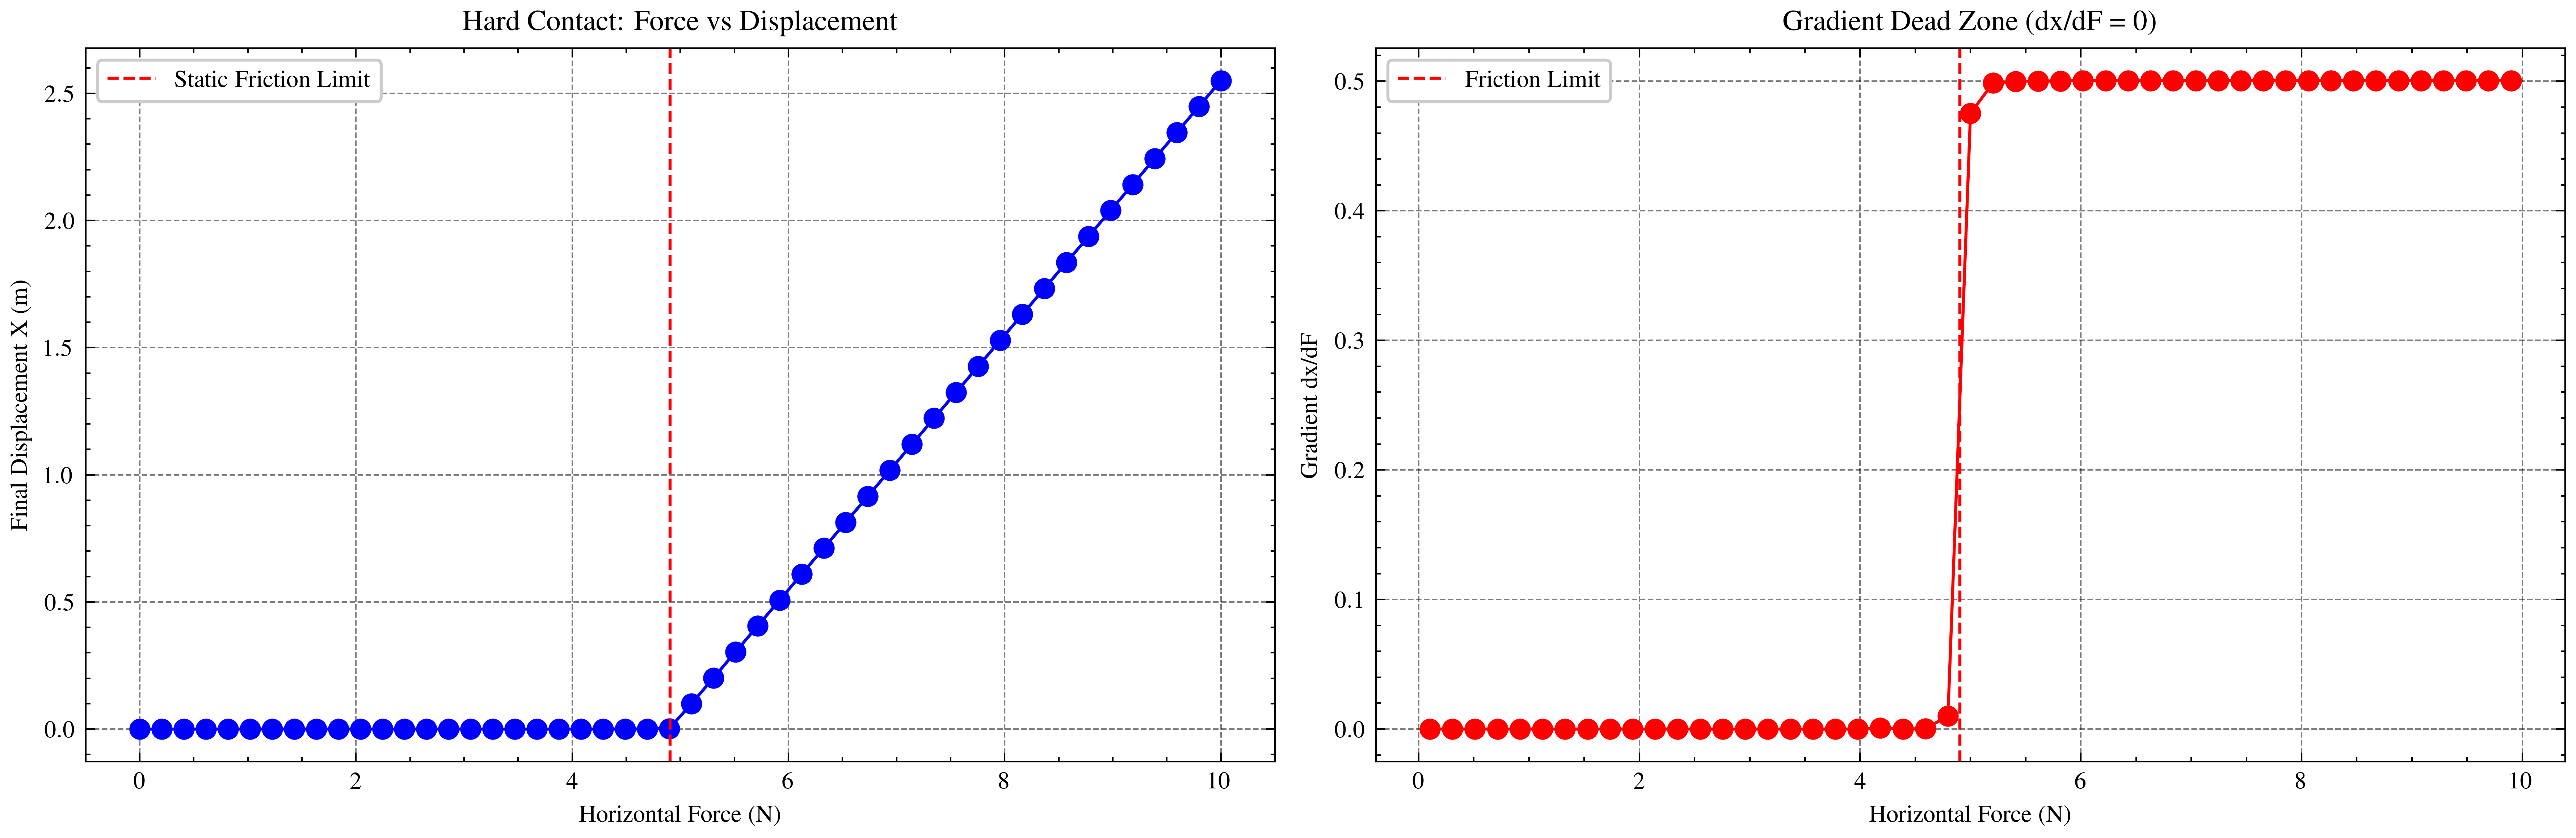

In [157]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt

def run_friction_push(force, dt=0.001, sim_time=1.0):
    p.connect(p.DIRECT)
    p.setGravity(0, 0, -9.81)
    p.setTimeStep(dt)
    
    # 使用纯硬约束
    p.setPhysicsEngineParameter(useSplitImpulse=True, contactERP=0.0)

    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    plane_id = p.loadURDF("plane.urdf")
    
    # 创建木箱 1kg
    mass = 1.0
    col_box = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.2, 0.2, 0.2])
    box_id = p.createMultiBody(baseMass=mass, baseCollisionShapeIndex=col_box, basePosition=[0, 0, 0.2])
    # 更新接触刚度（需同时设置地面和球体）
    p.changeDynamics(plane_id, -1, contactStiffness=1e6, contactDamping=0)
    # 修正1：达到实际mu=0.5，需设地表为1.0，木箱为0.5 (1.0 * 0.5 = 0.5)
    mu = 0.5
    p.changeDynamics(plane_id, -1, lateralFriction=1.0)
    
    # 修正2：必须关闭空气阻遏 linearDamping=0，否则受力系统不纯粹
    p.changeDynamics(box_id, -1, contactStiffness=1e6, contactDamping=0)
    p.changeDynamics(box_id, -1, lateralFriction=mu, linearDamping=0.0, angularDamping=0.0)

    # 持续施加水平推力
    for step in range(int(sim_time / dt)):
        p.applyExternalForce(box_id, -1, forceObj=[force, 0, 0], posObj=[0, 0, 0], flags=p.LINK_FRAME)
        p.stepSimulation()
        
    pos, _ = p.getBasePositionAndOrientation(box_id)
    p.disconnect()
    return pos[0]  # 返回X轴位移

# 测试推力从 0 到 10 N
force_range = np.linspace(0, 10, 50)
displacements = [run_friction_push(f) for f in force_range]

# 计算梯度 dx/dF
slopes = np.diff(displacements) / np.diff(force_range)
force_mid = (force_range[:-1] + force_range[1:]) / 2

# 绘图
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(force_range, displacements, 'b-o')
plt.axvline(x=4.905, color='r', linestyle='--', label='Static Friction Limit')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Final Displacement X (m)')
plt.title('Hard Contact: Force vs Displacement')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(force_mid, slopes, 'r-o')
plt.axvline(x=4.905, color='r', linestyle='--', label='Friction Limit')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Gradient dx/dF')
plt.title('Gradient Dead Zone (dx/dF = 0)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

正在运行 MuJoCo 仿真...


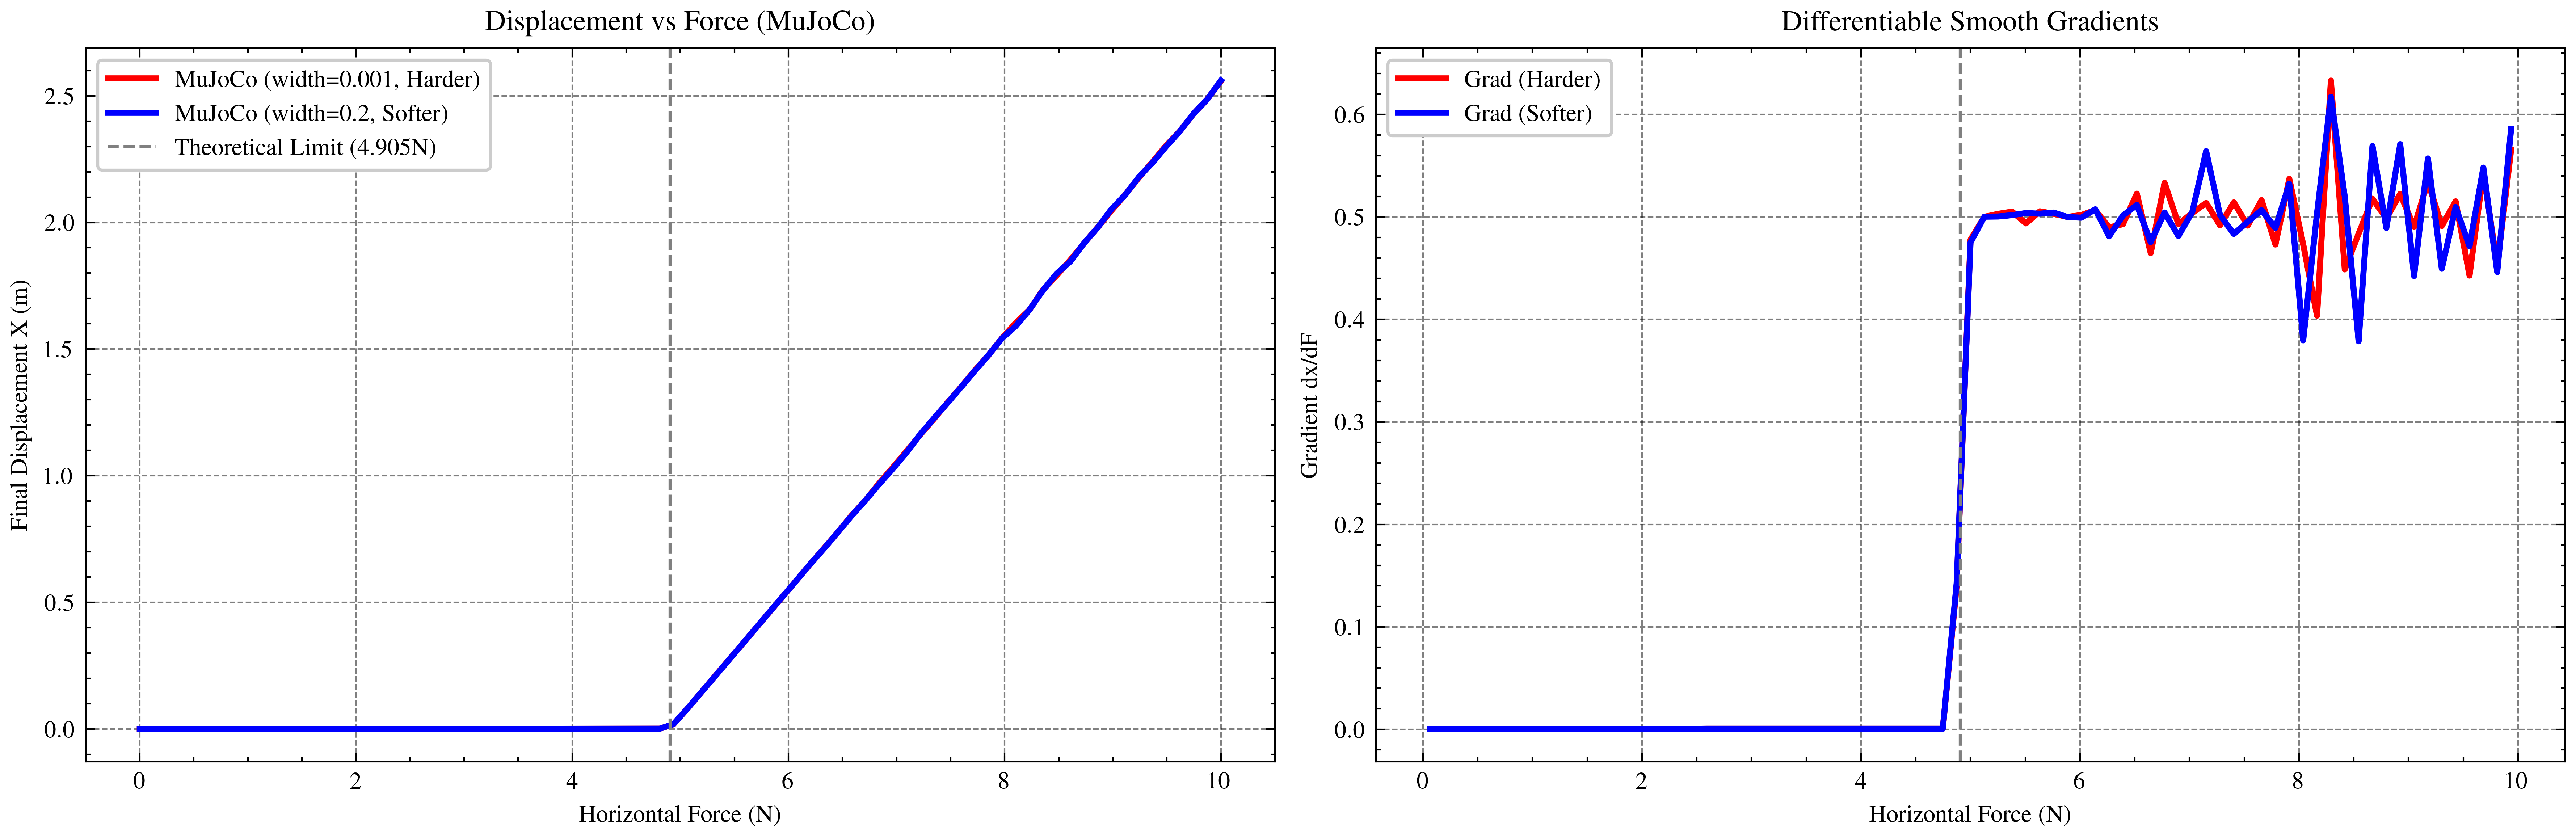

运行完毕。


In [158]:
# !pip install mujoco
import mujoco
import numpy as np
import matplotlib.pyplot as plt

def run_mujoco_push(force, friction_width=0.001, sim_time=1.0, dt=0.005):
    """
    friction_width: MuJoCo solimp的第3个参数，决定了静摩擦到动摩擦的"圆滑过渡宽度"
    参数越小越接近硬约束，参数越大过渡越平滑（适合梯度优化）
    """
    # 动态构建 MuJoCo XML
    xml = f"""
    <mujoco>
      <option timestep="{dt}" gravity="0 0 -9.81"/>
      <default>
         <!-- solimp="dmin dmax width midpoint power" 用于控制接触的平滑性 -->
         <geom solimp="0.95 0.99 {friction_width} 0.5 2" />
      </default>
      <worldbody>
        <light pos="0 0 10"/>
        <geom type="plane" size="10 10 0.1" friction="0.5 0 0"/>
        <body name="box" pos="0 0 0.05">
          <!-- 为了纯粹测试推进，限制为纯X轴和Z轴的平移，屏蔽旋转 -->
          <joint name="slide_x" type="slide" axis="1 0 0"/>
          <joint name="slide_z" type="slide" axis="0 0 1"/>
          <geom type="box" size="0.05 0.05 0.05" mass="1.0" friction="0.5 0 0"/>
        </body>
      </worldbody>
    </mujoco>
    """
    
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)

    # 1. 先让箱子自然掉落，稳定在地面上（建立法向力）
    for _ in range(200):
        mujoco.mj_step(model, data)
        
    # 2. 数据清零，准备推力测试
    data.qpos[0] = 0.0  # joint 0 是相对世界X轴的滑动位移
    data.qvel[:] = 0.0
    
    # 3. 持续施加力并积分
    steps = int(sim_time / dt)
    for _ in range(steps):
        # 针对第一个自由度 (slide_x) 施加力
        data.qfrc_applied[0] = force
        mujoco.mj_step(model, data)
        
    return data.qpos[0]

# 测试 0 到 10 N 的推力
force_range = np.linspace(0, 10, 80)
force_mid = (force_range[:-1] + force_range[1:]) / 2

print("正在运行 MuJoCo 仿真...")
# A. 接近硬接触（MuJoCo默认宽度 0.001）
disp_harder = [run_mujoco_push(f, friction_width=0.001) for f in force_range]
slopes_harder = np.diff(disp_harder) / np.diff(force_range)

# B. 极软摩擦接触（把过渡宽度拉大到了 0.2）
disp_softer = [run_mujoco_push(f, friction_width=0.2) for f in force_range]
slopes_softer = np.diff(disp_softer) / np.diff(force_range)

# 绘图
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(force_range, disp_harder, 'r-', lw=2, label='MuJoCo (width=0.001, Harder)')
plt.plot(force_range, disp_softer, 'b-', lw=2, label='MuJoCo (width=0.2, Softer)')
plt.axvline(x=4.905, color='gray', linestyle='--', label='Theoretical Limit (4.905N)')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Final Displacement X (m)')
plt.title('Displacement vs Force (MuJoCo)')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(force_mid, slopes_harder, 'r-', lw=2, label='Grad (Harder)')
plt.plot(force_mid, slopes_softer, 'b-', lw=2, label='Grad (Softer)')
plt.axvline(x=4.905, color='gray', linestyle='--')
plt.xlabel('Horizontal Force (N)'); plt.ylabel('Gradient dx/dF')
plt.title('Differentiable Smooth Gradients')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()
print("运行完毕。")